<font color='green'><div class="alert alert-success"><strong><H5>**Statistical Foundations for Machine Learning**<br>The numbers every ML practitioner must understand deeply</H5></strong>

<font color='black'><div class="alert alert-info"><strong>What you will learn</strong><br>

| Topic | Why it matters in ML |
|---|---|
| **Population** | All members of a group |
| **Sample** | The part of a selected population |
| **Variable** | A characteristic of an item that will be analysed |
| **Parameter** | A numerical value that describes a variable from a population |
| **Statistic** | A numerical value that describes a variable from a sample |
| **1. Central tendency** (mean, median, mode) | Typical value; imputation, EDA, reporting |
| **2. Variance & std** | Feature scaling, bias-variance tradeoff, noise |
| **3. Normal distribution & Z-scores** | How unusual is a value?; baseline for z-based outlier rules |
| **4. Percentiles (Q1, Q2, Q3)** | Robust summaries, box plots, IQR fences |
| **5. Skewness** | Symmetry and tail weight; transform or model choice |
| **6. Kurtosis** | Tail heaviness vs normal (excess kurtosis); fat tails → more extreme outliers; normality / residual checks for models that assume Gaussian noise |
| **7. Covariance** | Joint movement of two variables (scale-sensitive) |
| **8. Correlation** | Comparable linear association across features |
| **9-10. Outliers & feature scaling** | Data quality; `StandardScaler` vs `RobustScaler`; distance models |
| **11. synthesis** |  |
| **12. p-value, CIs, Type I/II** | Evidence under uncertainty; effect vs noise; decision errors |
| **13. Confidence interval** | Plausible range for a population parameter; uncertainty on offline metrics (e.g. mean AUC), A/B lift, and coefficients; sample-size / power thinking |
| **14. Type I & II** | False positive vs false negative costs; threshold tuning, precision–recall tradeoffs, and acceptance criteria for production decisions |
| **15. Reference plots** | Reusable EDA and diagnostics (hist, box, scatter, heatmap, fit + band, residuals, Q–Q); explain data shape and model behavior to stakeholders |

> **Philosophy**: These are not just formulas. Each one answers a specific question about your data. Understanding *what question it answers* is what makes you a better ML practitioner.

In [1]:
# Run this cell first in every fresh session — everything below assumes these imports and SEED (set SEED TO 42 if you want to reproduce my exactresults).
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
import seaborn as sns
from scipy import stats

In [4]:
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)

<font color='black'><div class="alert alert-info"><strong>1. Measures of central tendency</strong><br>

**What question do they answer?**

> *"If I had to summarise this batch of numbers with one (or a few) typical values, what should I report?"*

The three classical measures are the **mean**, **median**, and **mode**. Each summarises location differently and each reacts differently to skew and outliers.

| Measure | Idea | Formula / rule |
|---|---|---|
| **Mean** (arithmetic average) | Balance point of all values | $\displaystyle \bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i = \frac{x_1 + x_2 + \cdots + x_n}{n}$ |
| **Median** | Middle value after sorting | Sort $x_{(1)} \le \cdots \le x_{(n)}$. If $n$ is **odd**: median $= x_{((n+1)/2)}$. If $n$ is **even**: median $= \frac{1}{2}\bigl(x_{(n/2)} + x_{(n/2+1)}\bigr)$ |
| **Mode** | Most frequent value | Any $v$ with largest **count** among the $x_i$ (full formula below the table). **Ties** ⇒ several modes. **Continuous** data: bin first or use a density peak |

**Mode — formula** (same idea as counting how often each value appears, then pick the largest count):

$$\operatorname{mode} \in \arg\max_{v} \sum_{i=1}^{n} \mathbf{1}(x_i = v)$$

Here $\mathbf{1}(x_i = v)$ equals 1 when $x_i = v$ and 0 otherwise, so the sum is the frequency of $v$ in the sample.

**Rule of thumb**

| Situation | Prefer |
|---|---|
| Roughly symmetric, few outliers | Mean |
| Skewed data or outliers | Median |
| Categories or discrete codes | Mode |

<strong><font color='green'>The next code cell shows **manual** steps first (sum/count, sorted middle, frequency table), then the usual **NumPy / pandas** one-liners.</font>

In [5]:
# Central tendency: mean, median, mode

def mean_manual(x):
    """Mean = sum / count (same idea as np.mean)."""
    x = np.asarray(x, dtype=float)
    return float(x.sum() / x.size)


def median_manual(x):
    """Median = middle of sorted data; average two middles if n is even."""
    xs = np.sort(np.asarray(x, dtype=float))
    n = xs.size
    mid = n // 2
    if n % 2 == 1:
        return float(xs[mid])
    return float(0.5 * (xs[mid - 1] + xs[mid]))


def modes_from_counts(x):
    """Mode(s) = value(s) with highest frequency (great for teaching)."""
    vc = pd.Series(x).value_counts()
    top = vc.max()
    return vc[vc == top].index.tolist()


def central_tendency(arr, title):
    arr = np.asarray(arr, dtype=float)
    print(title)
    print(f"  data              : {arr}")
    print("   ========================== mean ==========================")
    print(f"  sum(x)/len(x)     : {mean_manual(arr):.4f}")
    print(f"  np.mean(x)        : {arr.mean():.4f}")
    print("  ========================== median =========================")
    print(f"  sort + middle     : {median_manual(arr):.4f}")
    print(f"  np.median(x)      : {np.median(arr):.4f}")
    print("  ================ mode (integers / discrete) ===============")
    print(f"  value_counts top  : {modes_from_counts(arr)}")
    print(f"  pd.Series.mode     : {pd.Series(arr).mode().tolist()}")

In [6]:
# Small smaple data
x_sym = np.array([2, 3, 3, 4, 5, 5, 5, 6])
x_skew = np.array([1, 2, 2, 3, 3, 100])
pets = pd.Series(["cat", "dog", "cat", "cat", "bird", "dog"])


central_tendency(x_sym, "A. Roughly symmetric counts")
central_tendency(x_skew, "B. Right-skewed (one large value pulls the mean)")

print("C. Categorical example")
print(f"  values              : {pets.tolist()}")
print("  value_counts()      :")
print(pets.value_counts().to_string(header=False))
print(f"  mode(s)             : {pets.mode().tolist()}")

A. Roughly symmetric counts
  data              : [2. 3. 3. 4. 5. 5. 5. 6.]
   ========================== mean ==========================
  sum(x)/len(x)     : 4.1250
  np.mean(x)        : 4.1250
  ========================== median =========================
  sort + middle     : 4.5000
  np.median(x)      : 4.5000
  ================ mode (integers / discrete) ===============
  value_counts top  : [5.0]
  pd.Series.mode     : [5.0]
B. Right-skewed (one large value pulls the mean)
  data              : [  1.   2.   2.   3.   3. 100.]
   ========================== mean ==========================
  sum(x)/len(x)     : 18.5000
  np.mean(x)        : 18.5000
  ========================== median =========================
  sort + middle     : 2.5000
  np.median(x)      : 2.5000
  ================ mode (integers / discrete) ===============
  value_counts top  : [2.0, 3.0]
  pd.Series.mode     : [2.0, 3.0]
C. Categorical example
  values              : ['cat', 'dog', 'cat', 'cat', 'bird', 'dog']


<font color='black'><div class="alert alert-info"><strong>Digging deeper: the mean (average)</strong><br>Section 1 introduced mean, median, and mode together. Here we focus on the mean because it drives MSE, StandardScaler, and baseline models.</div></font>

You already saw **mean, median, and mode** in section 1.

**What question does it answer?**
> *"If I had to describe this entire dataset with a single number, what is the most central value?"*

**The formula for Mean**
$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i = \frac{x_1 + x_2 + \cdots + x_n}{n}$$

While the formula might look confusing for some of you, it simply says: **add everything up, divide by the count.**


<font color='red'>**Why it matters in Machine Learning (ML)**</font><br>
| Use case | How mean is used |
|---|---|
| **Mean imputation** | Replace missing values with the column mean |
| **Mean Squared Error (MSE)** | Average of squared differences between predictions and actuals |
| **Feature scaling (StandardScaler)** | Subtracts the mean to centre data at 0 |
| **Baseline model** | Predicting the mean of $y$ for every observation is the simplest benchmark |
| **R² formula** | Measures improvement over predicting the mean |

<font color='red'>**The critical weakness: sensitivity to outliers**</font><br>
One extreme value can pull the mean far from where most data sits. This is why we also need the **median**.

<font color='green'><strong>Mean Example Fairly distributed values:</strong></font><br>
Dataset: daily sales at a small shop over 10 days (in £)<br>
</div></font>

In [7]:
# ── Mean vs median: same shop, with and without a crazy sales day ─────────
sales_normal = np.array([120, 135, 118, 142, 125, 130, 128, 115, 140, 127])
sales_outlier = np.array([120, 135, 118, 142, 125, 130, 128, 115, 140, 1200])

mean_normal = sales_normal.mean()
mean_outlier = sales_outlier.mean()
median_normal = np.median(sales_normal)
median_outlier = np.median(sales_outlier)

print('=== Normal 10 days sales ===')
print(f'  Values  : {sales_normal}')
print(f'  Mean    : £{mean_normal:.1f}')
print(f'  Median  : £{median_normal:.1f}')
print()
print('=== Sales with one outlier (£1200 event day) ===')
print(f'  Values  : {sales_outlier}')
print(f'  Mean    : £{mean_outlier:.1f}  ← pulled up by £{mean_outlier - mean_normal:.0f}')
print(f'  Median  : £{median_outlier:.1f}  ← barely moved')
print()
print('Takeaway: mean follows extreme values; median stays near the bulk of the data.')


=== Normal 10 days sales ===
  Values  : [120 135 118 142 125 130 128 115 140 127]
  Mean    : £128.0
  Median  : £127.5

=== Sales with one outlier (£1200 event day) ===
  Values  : [ 120  135  118  142  125  130  128  115  140 1200]
  Mean    : £235.3  ← pulled up by £107
  Median  : £129.0  ← barely moved

Takeaway: mean follows extreme values; median stays near the bulk of the data.


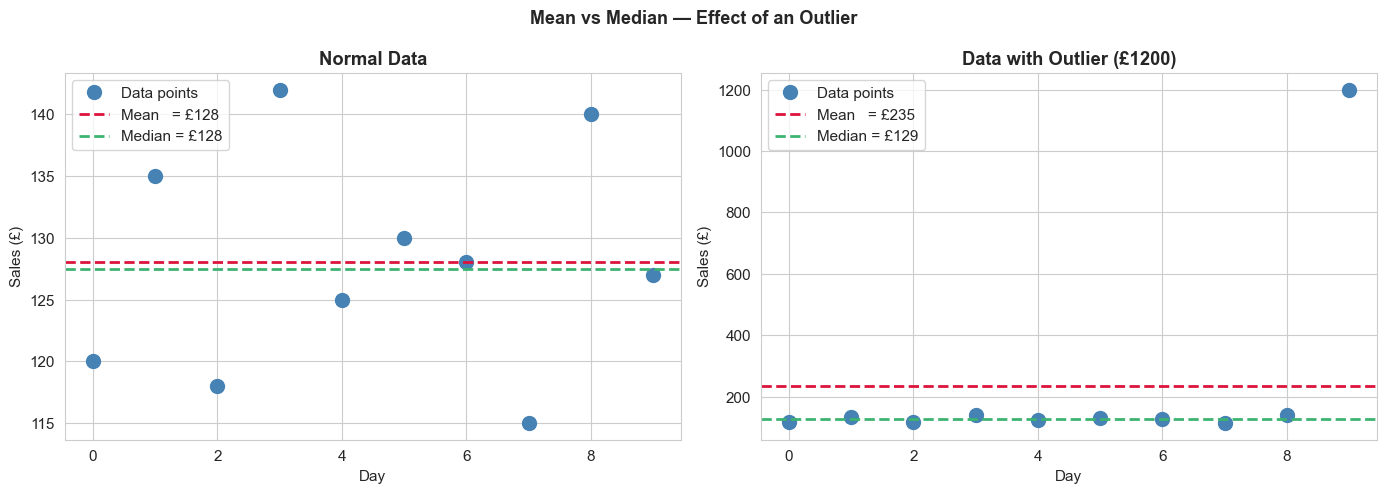

The mean chases the outlier. The median stays put.
→ In ML: use MEDIAN imputation for skewed features with outliers.


In [8]:
# ── Visualise mean vs median with and without outlier ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in zip(axes,
                            [sales_normal, sales_outlier],
                            ['Normal Data', 'Data with Outlier (£1200)']):
    ax.plot(data, 'o', color='steelblue', markersize=10, label='Data points')
    ax.axhline(data.mean(),   color='crimson',      linestyle='--', linewidth=2,
               label=f'Mean   = £{data.mean():.0f}')
    ax.axhline(np.median(data), color='mediumseagreen', linestyle='--', linewidth=2,
               label=f'Median = £{np.median(data):.0f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Day')
    ax.set_ylabel('Sales (£)')
    ax.legend()

plt.suptitle('Mean vs Median — Effect of an Outlier', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('The mean chases the outlier. The median stays put.')
print('→ In ML: use MEDIAN imputation for skewed features with outliers.')

<font color='black'><div class="alert alert-info"><strong>2. Variance and Standard Deviation</strong></div><br>

**What question do they answer?**
> *"How spread out are the values? How far do they typically stray from the mean?"*

<font color='red'>**The formulas**</font><br>

**Variance** — average of squared distances from the mean:
$$\sigma^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

**Standard Deviation** — square root of variance (same units as the data):
$$\sigma = \sqrt{\sigma^2}$$

### Why square the differences?
- Raw differences cancel out (positives + negatives = 0)
- Squaring makes them all positive AND penalises large deviations more than small ones
- Taking the square root at the end puts us back in the original units

## Why they matter in ML

| Use case | How variance/std is used |
|---|---|
| **Feature scaling** | StandardScaler divides by std to make all features comparable |
| **Constant feature detection** | Variance = 0 → feature carries zero information |
| **Bias-variance tradeoff** | High model variance = overfitting; high bias = underfitting |
| **Normal distribution** | std defines the spread of the bell curve — 68%/95%/99.7% rule |
| **MSE loss function** | Mean Squared Error is the average variance of prediction errors |

In [9]:
# ── Variance: Build it step by step ───────────────────────────────────────
# Five exam marks — same "classroom story" style as the mean section.
scores = np.array([70, 75, 80, 85, 90])
mean_score = scores.mean()

print('Scores:', scores)
print(f'Mean  : {mean_score}')
print()
print(f'{"Score":<10} {"Deviation":<20} {"Squared Deviation":<20}')
print('-' * 50)
sq_devs = []
for x in scores:
    dev     = x - mean_score
    sq_dev  = dev ** 2
    sq_devs.append(sq_dev)
    print(f'{x:<10} {dev:<20.1f} {sq_dev:<20.1f}')

variance = np.mean(sq_devs)
std_dev  = np.sqrt(variance)
print('-' * 50)
print(f'Sum of squared deviations : {sum(sq_devs):.1f}')
print(f'Variance (÷ n)            : {variance:.2f}')
print(f'Standard Deviation (√var) : {std_dev:.2f}')
print()
print(f'numpy verification — var: {np.var(scores):.2f}  std: {np.std(scores):.2f}')

Scores: [70 75 80 85 90]
Mean  : 80.0

Score      Deviation            Squared Deviation   
--------------------------------------------------
70         -10.0                100.0               
75         -5.0                 25.0                
80         0.0                  0.0                 
85         5.0                  25.0                
90         10.0                 100.0               
--------------------------------------------------
Sum of squared deviations : 250.0
Variance (÷ n)            : 50.00
Standard Deviation (√var) : 7.07

numpy verification — var: 50.00  std: 7.07


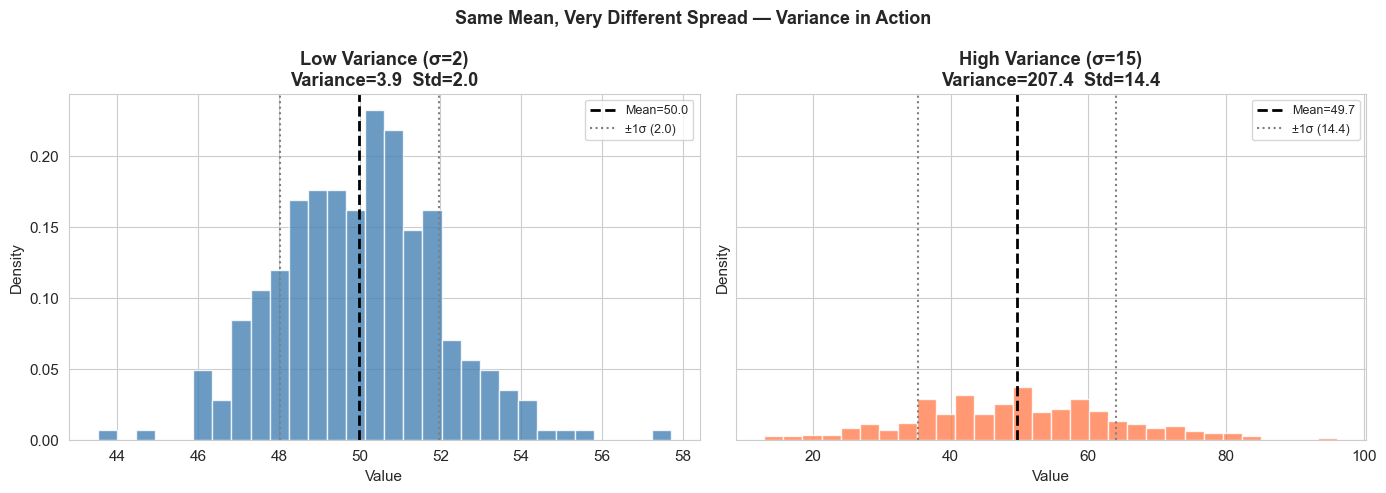

Same mean (≈50), but completely different distributions.
→ In ML: two features with the same mean but different variance behave differently.
→ StandardScaler fixes this by dividing each feature by its std.

The 68–95–99.7 Rule (for normal distributions):
  ~68% of data falls within ±1σ of the mean
  ~95% of data falls within ±2σ of the mean
  ~99.7% of data falls within ±3σ of the mean
  → Values beyond ±3σ are statistical outliers.


In [10]:
# ── Low vs High Variance — what it looks like ─────────────────────────────
# Same mean (50), different σ: narrow vs wide bell; grey lines = mean ± 1σ.
np.random.seed(SEED)
low_var  = np.random.normal(loc=50, scale=2,  size=300)  # tight cluster
high_var = np.random.normal(loc=50, scale=15, size=300)  # spread out

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, data, label, colour in zip(
    axes,
    [low_var, high_var],
    ['Low Variance (σ=2)', 'High Variance (σ=15)'],
    ['steelblue', 'coral']
):
    ax.hist(data, bins=30, color=colour, edgecolor='white', alpha=0.8, density=True)
    ax.axvline(data.mean(), color='black',  linestyle='--', linewidth=2, label=f'Mean={data.mean():.1f}')
    ax.axvline(data.mean() - data.std(), color='grey', linestyle=':', linewidth=1.5, label=f'±1σ ({data.std():.1f})')
    ax.axvline(data.mean() + data.std(), color='grey', linestyle=':', linewidth=1.5)
    ax.set_title(f'{label}\nVariance={np.var(data):.1f}  Std={np.std(data):.1f}', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Same Mean, Very Different Spread — Variance in Action', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Same mean (≈50), but completely different distributions.')
print('→ In ML: two features with the same mean but different variance behave differently.')
print('→ StandardScaler fixes this by dividing each feature by its std.')
print()
print('The 68–95–99.7 Rule (for normal distributions):')
print('  ~68% of data falls within ±1σ of the mean')
print('  ~95% of data falls within ±2σ of the mean')
print('  ~99.7% of data falls within ±3σ of the mean')
print('  → Values beyond ±3σ are statistical outliers.')

<font color='black'><div class="alert alert-info"><strong>3. The Normal Distribution</strong><br>

**What question does it answer?**
> *"What does a 'natural' spread of random data look like, and how likely is any particular value?"*

## Why it matters more than any other distribution in ML

The normal distribution (a.k.a. **Gaussian** or **bell curve**) appears naturally whenever a
measurement is the result of many small independent random effects — heights, measurement errors,
residuals from a well-fitted regression model.

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

Two parameters fully describe it:
- **μ (mu)** — the mean — where the centre of the bell sits
- **σ (sigma)** — the standard deviation — how wide or narrow the bell is<br>

<font color='green'>**The 68–95–99.7 Rule (Empirical Rule)**</font>

| Range | % of data contained |
|---|---|
| μ ± 1σ | ~68% |
| μ ± 2σ | ~95% |
| μ ± 3σ | ~99.7% |

This rule is used for **outlier detection** (values beyond ±3σ are rare), **feature scaling**,
and understanding **residuals** in regression.<br>

**The Standard Normal (Z-distribution)**<br><br>
When μ=0 and σ=1 we call it the **standard normal**. Converting any normal value to this scale
is called **standardisation**:
$$Z = \frac{x - \mu}{\sigma}$$
Z tells you: *"how many standard deviations is this value from the mean?"*

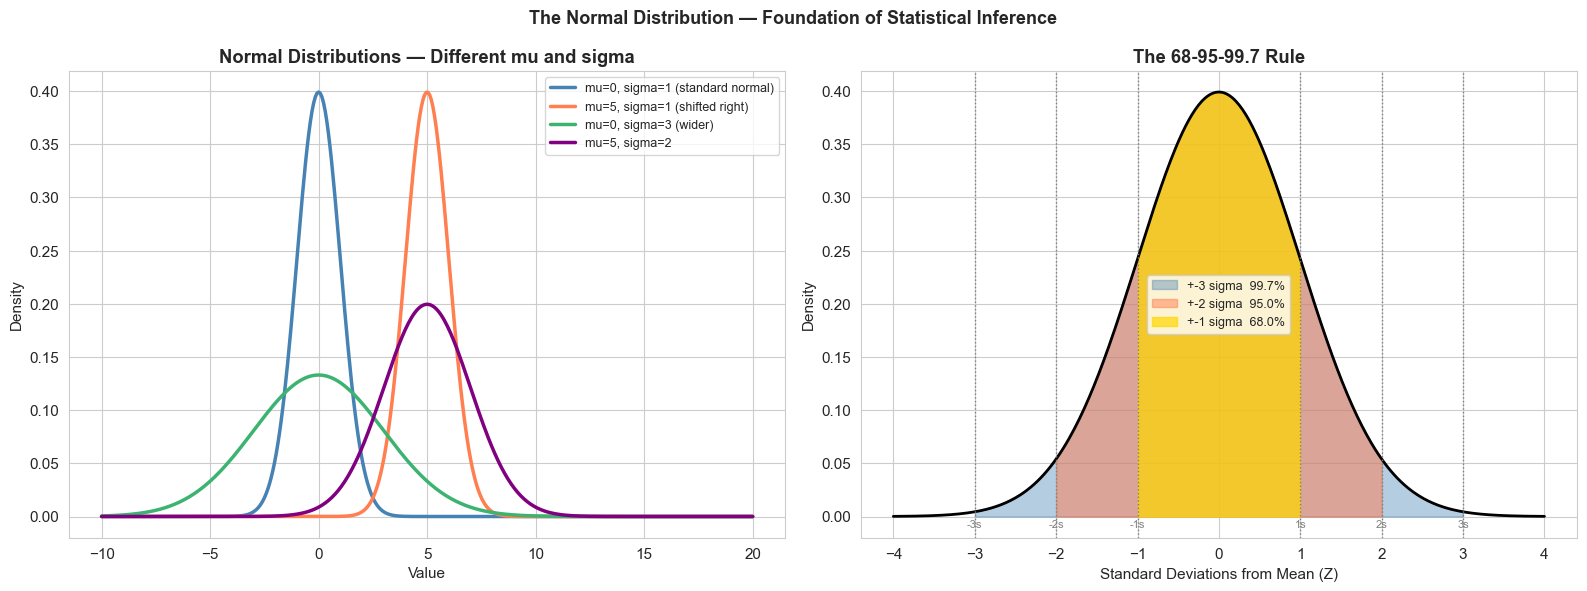

Z-score examples:
  Z = 0  ->  50.0% of data falls BELOW this point
  Z = 1  ->  84.1% of data falls BELOW this point
  Z = 2  ->  97.7% of data falls BELOW this point
  Z = 3  ->  99.9% of data falls BELOW this point


In [20]:
# ── Normal Distribution: Bell curve + 68-95-99.7 rule ───────────────────
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.linspace(-10, 20, 400)
for mu, sigma, label, colour in [
    (0, 1, 'mu=0, sigma=1 (standard normal)', 'steelblue'),
    (5, 1, 'mu=5, sigma=1 (shifted right)',   'coral'),
    (0, 3, 'mu=0, sigma=3 (wider)',           'mediumseagreen'),
    (5, 2, 'mu=5, sigma=2',                   'purple'),
]:
    axes[0].plot(x, norm.pdf(x, mu, sigma), linewidth=2.5, label=label, color=colour)
axes[0].set_title('Normal Distributions — Different mu and sigma', fontweight='bold')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Density'); axes[0].legend(fontsize=9)

x_std = np.linspace(-4, 4, 400)
y_std = norm.pdf(x_std)
axes[1].plot(x_std, y_std, 'k-', linewidth=2)
for s, c, a, label in [(3,'steelblue',0.4,'+-3 sigma  99.7%'),
                        (2,'coral',    0.5,'+-2 sigma  95.0%'),
                        (1,'gold',     0.7,'+-1 sigma  68.0%')]:
    axes[1].fill_between(x_std, y_std, where=(np.abs(x_std) <= s),
                         color=c, alpha=a, label=label)
for s in [-3,-2,-1,1,2,3]:
    axes[1].axvline(s, color='grey', linestyle=':', linewidth=1)
    axes[1].text(s, -0.01, f'{s}s', ha='center', fontsize=8, color='grey')
axes[1].set_title('The 68-95-99.7 Rule', fontweight='bold')
axes[1].set_xlabel('Standard Deviations from Mean (Z)'); axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)
plt.suptitle('The Normal Distribution — Foundation of Statistical Inference',
             fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

print('Z-score examples:')
for z in [0, 1, 2, 3]:
    print(f'  Z = {z}  ->  {norm.cdf(z)*100:.1f}% of data falls BELOW this point')

In [21]:
# ── Z-score: how unusual is this value? ──────────────────────────────────
# Exam: mean=70, std=10
mu_exam, sigma_exam = 70, 10

print('=== Z-score Interpretation ===')
print(f'Exam scores: mean={mu_exam}, std={sigma_exam}')
print()
print(f'{"Score":<10} {"Z-score":<12} {"Percentile":<15} {"Flag"}')
print('-' * 62)
for score in [55, 65, 70, 80, 95]:
    z   = (score - mu_exam) / sigma_exam
    pct = norm.cdf(z) * 100
    flag = ' <- outlier (beyond +-2 std)' if abs(z) > 2 else ''
    print(f'{score:<10} {z:<12.2f} {pct:<15.1f}% {flag}')

print()
print('Rule of thumb in ML:')
print('  |Z| > 2  -> unusual  (outside 95% of data)')
print('  |Z| > 3  -> very unusual  (outside 99.7% -- statistical outlier)')

=== Z-score Interpretation ===
Exam scores: mean=70, std=10

Score      Z-score      Percentile      Flag
--------------------------------------------------------------
55         -1.50        6.7            % 
65         -0.50        30.9           % 
70         0.00         50.0           % 
80         1.00         84.1           % 
95         2.50         99.4           %  <- outlier (beyond +-2 std)

Rule of thumb in ML:
  |Z| > 2  -> unusual  (outside 95% of data)
  |Z| > 3  -> very unusual  (outside 99.7% -- statistical outlier)


<font color='black'><div class="alert alert-info"><strong>4. Q1, Q2, Q3 — Quartiles and Percentiles</strong><br>

**What question do they answer?**
> *"Where do the bottom 25%, middle 50%, and top 25% of my data begin?"*

<font color='red'>**Definitions**</font>

A **percentile** answers: *"What value has P% of the data below it?"*

**Quartiles** are the most commonly used percentiles:

| Name | Percentile | Meaning |
|---|---|---|
| **Q1** (First quartile) | 25th percentile | 25% of values are below this point |
| **Q2** (Second quartile = **Median**) | 50th percentile | 50% below, 50% above |
| **Q3** (Third quartile) | 75th percentile | 75% of values are below this point |
| **IQR** (Interquartile Range) | Q3 − Q1 | The middle 50% of the data |

**Why they matter in ML**

| Use case | How quartiles are used |
|---|---|
| **Box plot** | Visualise the full distribution: median, spread, outliers |
| **Outlier detection** | IQR rule: values outside Q1−1.5×IQR or Q3+1.5×IQR are outliers |
| **Robust scaling** | `RobustScaler` uses Q1/Q3 instead of mean/std — immune to outliers |
| **Median imputation** | Q2 is the median — the robust alternative to mean imputation |
| **Percentile clipping** | Cap outliers at the 1st and 99th percentile |

In [23]:
# ── Quartiles: Step by Step ────────────────────────────────────────────────
# Dataset: house prices (£k) in a neighbourhood
# Toy data: 18 house prices (£k).
house_prices = np.array([150, 175, 180, 200, 210, 220, 225, 230, 250, 260,270, 280, 290, 310, 350, 400, 500, 650])

Q1  = np.percentile(house_prices, 25)
Q2  = np.percentile(house_prices, 50)  # = median
Q3  = np.percentile(house_prices, 75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = house_prices[(house_prices < lower_fence) | (house_prices > upper_fence)]

print('House prices (£k):', house_prices)
print()
print(f'Q1  (25th pct) = £{Q1}k   → 25% of houses cost LESS than this')
print(f'Q2  (median)   = £{Q2}k   → half the houses cost more, half cost less')
print(f'Q3  (75th pct) = £{Q3}k   → 75% of houses cost LESS than this')
print(f'IQR            = £{IQR}k  → the middle 50% of houses span this range')
print()
print(f'IQR Outlier fences:')
print(f'  Lower fence : Q1 − 1.5×IQR = {lower_fence:.0f} (no houses below this)')
print(f'  Upper fence : Q3 + 1.5×IQR = {upper_fence:.0f}')
print(f'  Outliers detected: £{outliers}k')

House prices (£k): [150 175 180 200 210 220 225 230 250 260 270 280 290 310 350 400 500 650]

Q1  (25th pct) = £212.5k   → 25% of houses cost LESS than this
Q2  (median)   = £255.0k   → half the houses cost more, half cost less
Q3  (75th pct) = £305.0k   → 75% of houses cost LESS than this
IQR            = £92.5k  → the middle 50% of houses span this range

IQR Outlier fences:
  Lower fence : Q1 − 1.5×IQR = 74 (no houses below this)
  Upper fence : Q3 + 1.5×IQR = 444
  Outliers detected: £[500 650]k


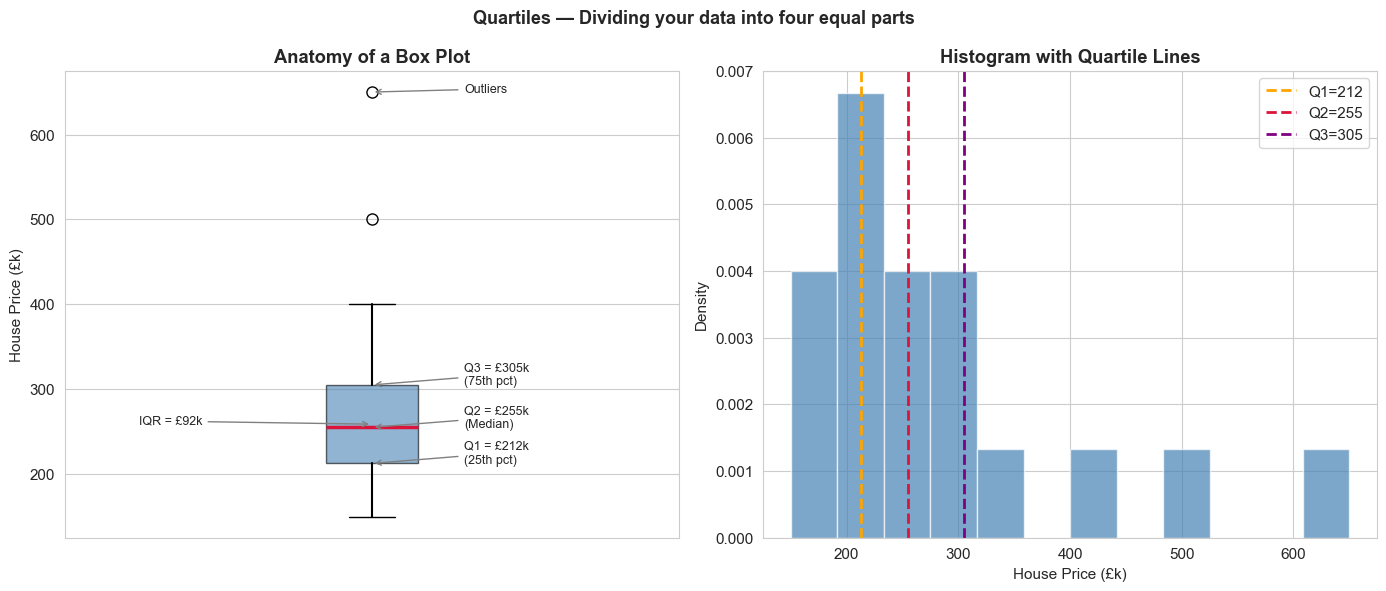

Box plot reading guide:
  Bottom of box  = Q1  |  Middle line = Q2 (median)  |  Top of box = Q3
  Box width      = IQR (middle 50% of data)
  Whiskers extend to last point within 1.5×IQR
  Individual dots beyond whiskers = outliers


In [8]:
# ── Anatomy of a Box Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: annotated box plot
bp = axes[0].boxplot(house_prices, vert=True, patch_artist=True,
                      boxprops=dict(facecolor='steelblue', alpha=0.6),
                      medianprops=dict(color='crimson', linewidth=2.5),
                      whiskerprops=dict(linewidth=1.5),
                      flierprops=dict(marker='o', color='orange', markersize=8))

# Annotations
annotations = {
    f'Q1 = £{Q1:.0f}k\n(25th pct)': (1.15, Q1),
    f'Q2 = £{Q2:.0f}k\n(Median)':   (1.15, Q2),
    f'Q3 = £{Q3:.0f}k\n(75th pct)': (1.15, Q3),
    f'IQR = £{IQR:.0f}k':           (0.62, (Q1+Q3)/2),
    f'Outliers':                    (1.15, 650)
}
for text, (x, y) in annotations.items():
    axes[0].annotate(text, xy=(1, y), xytext=(x, y),
                     fontsize=9, ha='left',
                     arrowprops=dict(arrowstyle='->', color='grey', lw=1))

axes[0].set_title('Anatomy of a Box Plot', fontweight='bold')
axes[0].set_ylabel('House Price (£k)')
axes[0].set_xticks([])

# Right: histogram overlaid with quartile lines
axes[1].hist(house_prices, bins=12, color='steelblue', edgecolor='white', alpha=0.7, density=True)
for val, label, colour in [
    (Q1, f'Q1={Q1:.0f}', 'orange'),
    (Q2, f'Q2={Q2:.0f}', 'crimson'),
    (Q3, f'Q3={Q3:.0f}', 'purple')
]:
    axes[1].axvline(val, color=colour, linestyle='--', linewidth=2, label=label)
axes[1].set_title('Histogram with Quartile Lines', fontweight='bold')
axes[1].set_xlabel('House Price (£k)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Quartiles — Dividing your data into four equal parts', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Box plot reading guide:')
print('  Bottom of box  = Q1  |  Middle line = Q2 (median)  |  Top of box = Q3')
print('  Box width      = IQR (middle 50% of data)')
print('  Whiskers extend to last point within 1.5×IQR')
print('  Individual dots beyond whiskers = outliers')

<font color='black'><div class="alert alert-info"><strong>5. Skewness</strong><br>

**What question does it answer?**
> *"Is my distribution symmetric, or does it have a long tail pulling to one side?"*

<font color='red'>**The formula**</font>

$$\text{Skewness} = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{\sigma}\right)^3$$

It is the **average of cubed standardised deviations**. Cubing preserves sign (positive = right, negative = left) and amplifies large deviations.

**How to interpret it**

| Skewness value | Distribution shape | Example |
|---|---|---|
| ≈ 0 | Symmetric (normal-like) | Heights of adults |
| **> 0** (positive skew) | **Right tail is longer** — most values low, a few very high | Income, house prices, population |
| **< 0** (negative skew) | **Left tail is longer** — most values high, a few very low | Exam scores in an easy test |
| \|skew\| < 0.5 | Approximately symmetric |  No transformation needed |
| \|skew\| 0.5–1.0 | Moderately skewed |  Consider log/sqrt transform |
| \|skew\| > 1.0 | Highly skewed |  Transform before linear modelling |

**Why it matters in ML**

| Impact | Consequence |
|---|---|
| **Linear regression** | Skewed features don't violate linearity *directly*, but skewed residuals suggest a poor model fit |
| **Imputation** | Skewed data → use median, not mean |
| **Outlier detection** | Skewed data → IQR method works better than ±3σ |
| **Neural networks / tree models** | Less sensitive to skewness, but log-transform still often helps |

**The key visual trick**
> In a **right-skewed** distribution: **mean > median > mode**
> The mean is pulled toward the long tail.

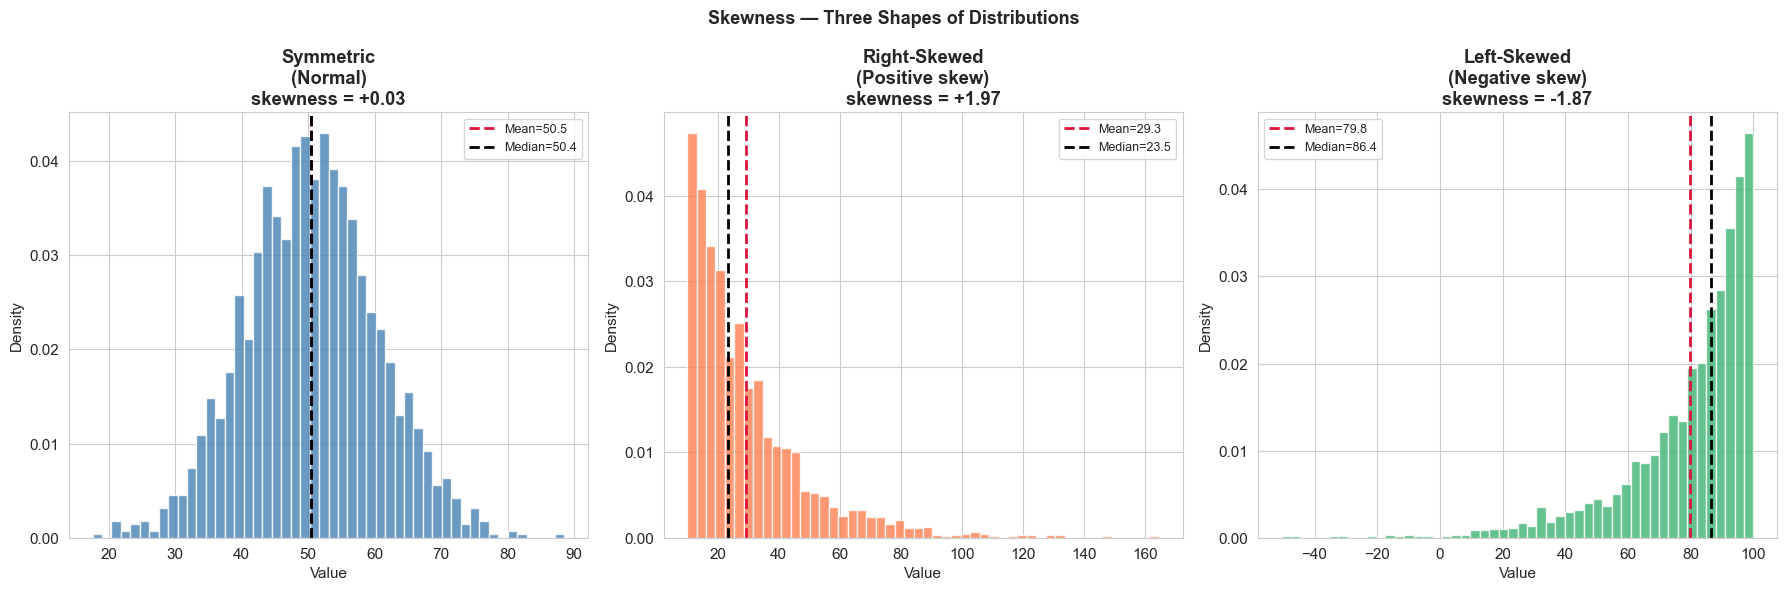

Notice in right-skewed: mean > median (tail pulls mean right)
Notice in left-skewed : mean < median (tail pulls mean left)
In symmetric         : mean ≈ median


In [24]:
# ── Three distributions: symmetric, right-skewed, left-skewed ─────────────
np.random.seed(SEED)
n = 2000

sym_data   = np.random.normal(50, 10, n)
right_data = np.random.exponential(scale=20, size=n) + 10   # Right-skewed
left_data  = 100 - np.random.exponential(scale=20, size=n)  # Left-skewed

datasets = [
    (sym_data,   'Symmetric\n(Normal)', 'steelblue'),
    (right_data, 'Right-Skewed\n(Positive skew)', 'coral'),
    (left_data,  'Left-Skewed\n(Negative skew)', 'mediumseagreen'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (data, title, colour) in zip(axes, datasets):
    ax.hist(data, bins=50, color=colour, edgecolor='white', alpha=0.8, density=True)
    ax.axvline(np.mean(data),   color='crimson',      linestyle='--', linewidth=2,
               label=f'Mean={np.mean(data):.1f}')
    ax.axvline(np.median(data), color='black',        linestyle='--', linewidth=2,
               label=f'Median={np.median(data):.1f}')
    skew_val = stats.skew(data)
    ax.set_title(f'{title}\nskewness = {skew_val:+.2f}', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Skewness — Three Shapes of Distributions', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Notice in right-skewed: mean > median (tail pulls mean right)')
print('Notice in left-skewed : mean < median (tail pulls mean left)')
print('In symmetric         : mean ≈ median')

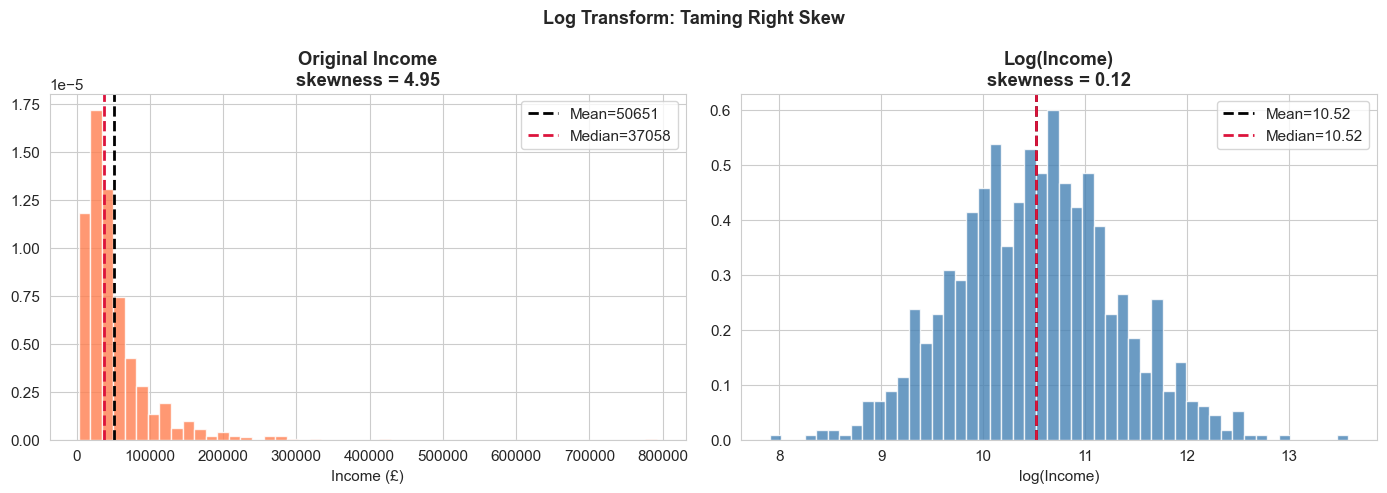

After log transform: skewness drops dramatically, mean ≈ median.
→ Use log(x) for right-skewed positive features before linear regression.
→ Use np.log1p(x) if your data contains zeros (log(0) is undefined).


In [25]:
# ── Log Transform: Fixing Right Skew ──────────────────────────────────────
# Example: income data (heavily right-skewed)
np.random.seed(SEED)
income = np.random.lognormal(mean=10.5, sigma=0.8, size=1000)  # in £

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original
axes[0].hist(income, bins=50, color='coral', edgecolor='white', alpha=0.8, density=True)
axes[0].axvline(income.mean(), color='black', linestyle='--', linewidth=2,
                label=f'Mean={income.mean():.0f}')
axes[0].axvline(np.median(income), color='crimson', linestyle='--', linewidth=2,
                label=f'Median={np.median(income):.0f}')
axes[0].set_title(f'Original Income\nskewness = {stats.skew(income):.2f}', fontweight='bold')
axes[0].set_xlabel('Income (£)')
axes[0].legend()

# Log-transformed
log_income = np.log(income)
axes[1].hist(log_income, bins=50, color='steelblue', edgecolor='white', alpha=0.8, density=True)
axes[1].axvline(log_income.mean(), color='black', linestyle='--', linewidth=2,
                label=f'Mean={log_income.mean():.2f}')
axes[1].axvline(np.median(log_income), color='crimson', linestyle='--', linewidth=2,
                label=f'Median={np.median(log_income):.2f}')
axes[1].set_title(f'Log(Income)\nskewness = {stats.skew(log_income):.2f}', fontweight='bold')
axes[1].set_xlabel('log(Income)')
axes[1].legend()

plt.suptitle('Log Transform: Taming Right Skew', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('After log transform: skewness drops dramatically, mean ≈ median.')
print('→ Use log(x) for right-skewed positive features before linear regression.')
print('→ Use np.log1p(x) if your data contains zeros (log(0) is undefined).')

<font color='black'><div class="alert alert-info"><strong>6. Kurtosis</strong><br>

**What question does it answer?**
> *"How heavy are the tails of my distribution? Are extreme values more or less common than normal?"*

Skewness tells you about **asymmetry**. Kurtosis tells you about **tail heaviness** — independently of skew.

<font color='red'>**The formula**</font>

$$\text{Kurtosis} = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{\sigma}\right)^4$$

The **excess kurtosis** (used by scipy and pandas) subtracts 3 so a normal distribution = 0:
$$\text{Excess Kurtosis} = \text{Kurtosis} - 3$$

**Interpretation**

| Excess Kurtosis | Type | Description | Example |
|---|---|---|---|
| = 0 | **Mesokurtic** | Normal tails (benchmark) | Height of adults |
| **> 0** | **Leptokurtic** | **Heavy/fat tails** — more extreme values than normal | Stock returns, financial data |
| **< 0** | **Platykurtic** | **Light/thin tails** — fewer extreme values than normal | Uniform distribution |

**Why it matters in ML**

| Impact | Consequence |
|---|---|
| **Outliers** | High kurtosis = fat tails = more extreme outliers to deal with |
| **Normality check** | Both skew AND kurtosis must be near 0 for normality |
| **Risk / anomaly detection** | Fat-tailed data means rare events are more common than you'd expect |
| **Regression residuals** | High kurtosis residuals = non-normality → revisit model assumptions |

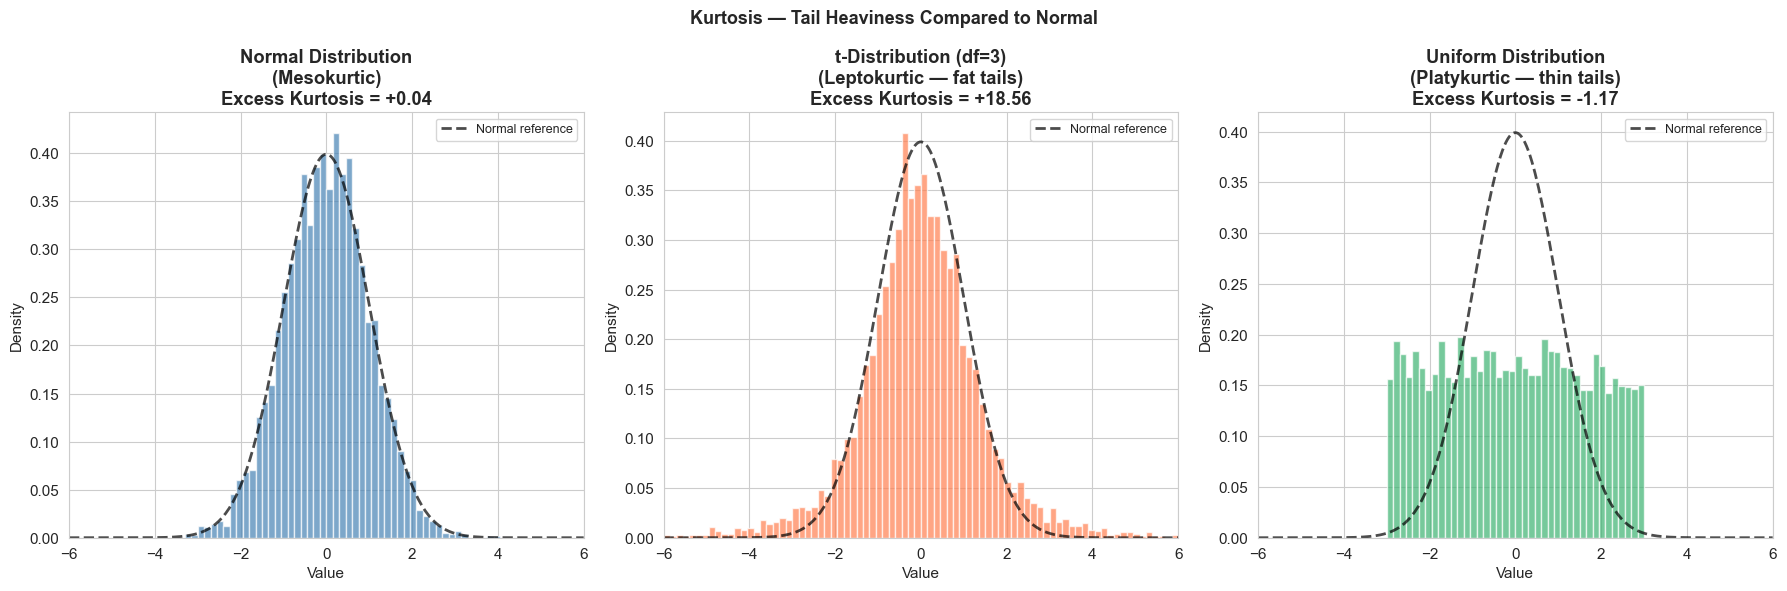

Key insight:
  Leptokurtic (excess kurtosis > 0): the tails are FATTER than normal.
  → Extreme values occur more often than you'd expect.
  → This is why stock markets crash more often than normal models predict.

  Platykurtic (excess kurtosis < 0): the tails are THINNER than normal.
  → Extreme values are rarer than a normal distribution would suggest.


In [27]:
# ── Kurtosis: Three tail shapes ────────────────────────────────────────────
np.random.seed(SEED)
n = 5000

normal_data  = np.random.normal(0, 1, n)              # Mesokurtic (excess kurtosis ≈ 0)
fat_tail     = np.random.standard_t(df=3, size=n)     # Leptokurtic (fat tails)
thin_tail    = np.random.uniform(-3, 3, size=n)       # Platykurtic (thin tails)

datasets_kurt = [
    (normal_data, 'Normal Distribution\n(Mesokurtic)', 'steelblue'),
    (fat_tail,    "t-Distribution (df=3)\n(Leptokurtic — fat tails)", 'coral'),
    (thin_tail,   'Uniform Distribution\n(Platykurtic — thin tails)', 'mediumseagreen'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

x_range = np.linspace(-6, 6, 300)
normal_pdf = stats.norm.pdf(x_range)

for ax, (data, title, colour) in zip(axes, datasets_kurt):
    ax.hist(data, bins=80, color=colour, edgecolor='white', alpha=0.7, density=True,
            range=(-6, 6))
    ax.plot(x_range, normal_pdf, 'k--', linewidth=2, alpha=0.7, label='Normal reference')
    kurt_val = stats.kurtosis(data)  # excess kurtosis
    ax.set_title(f'{title}\nExcess Kurtosis = {kurt_val:+.2f}', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.set_xlim(-6, 6)
    ax.legend(fontsize=9)

plt.suptitle('Kurtosis — Tail Heaviness Compared to Normal', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Key insight:')
print('  Leptokurtic (excess kurtosis > 0): the tails are FATTER than normal.')
print('  → Extreme values occur more often than you\'d expect.')
print('  → This is why stock markets crash more often than normal models predict.')
print()
print('  Platykurtic (excess kurtosis < 0): the tails are THINNER than normal.')
print('  → Extreme values are rarer than a normal distribution would suggest.')

In [28]:
# ── Skew and Kurtosis together: Summary Table ─────────────────────────────
datasets_summary = {
    'Normal scores (exam)'    : np.random.normal(70, 10, 1000),
    'Income (right-skewed)'   : np.random.lognormal(10, 0.8, 1000),
    'Exam (easy, left-skew)'  : 100 - np.random.exponential(10, 1000),
    'Stock returns (fat tail)': np.random.standard_t(3, 1000),
    'Uniform distribution'    : np.random.uniform(0, 100, 1000)
}

rows = []
for name, data in datasets_summary.items():
    rows.append({
        'Dataset'         : name,
        'Mean'            : round(np.mean(data), 2),
        'Median'          : round(np.median(data), 2),
        'Std'             : round(np.std(data), 2),
        'Skewness'        : round(stats.skew(data), 2),
        'Excess Kurtosis' : round(stats.kurtosis(data), 2)
    })

summary_df = pd.DataFrame(rows).set_index('Dataset')
print('=== Skew + Kurtosis Summary Table ===')
print(summary_df.to_string())
print()
print('Interpretation columns:')
print('  Skewness ≈ 0       → symmetric')
print('  Skewness > 0       → right tail (mean > median)')
print('  Skewness < 0       → left tail  (mean < median)')
print('  Exc. Kurtosis ≈ 0  → normal tails')
print('  Exc. Kurtosis > 0  → fat tails (more outliers than expected)')
print('  Exc. Kurtosis < 0  → thin tails')

=== Skew + Kurtosis Summary Table ===
                              Mean    Median       Std  Skewness  Excess Kurtosis
Dataset                                                                          
Normal scores (exam)         70.18     70.13      9.64      0.10            -0.11
Income (right-skewed)     29030.70  21987.74  25890.65      3.81            32.42
Exam (easy, left-skew)       90.28     92.90      9.33     -1.82             4.32
Stock returns (fat tail)     -0.03     -0.01      1.82      2.91            45.93
Uniform distribution         50.36     51.48     28.79     -0.01            -1.22

Interpretation columns:
  Skewness ≈ 0       → symmetric
  Skewness > 0       → right tail (mean > median)
  Skewness < 0       → left tail  (mean < median)
  Exc. Kurtosis ≈ 0  → normal tails
  Exc. Kurtosis > 0  → fat tails (more outliers than expected)
  Exc. Kurtosis < 0  → thin tails


---
# 7. Covariance

**Why this sits just before correlation:** covariance uses the *original units* of $X$ and $Y$, so you cannot fairly compare it across pairs of features. The next section rescales that idea into **correlation**, which is always between $-1$ and $1$.

## What question does it answer?
> *"When X goes above its mean, does Y tend to go above its mean too?"*

## The formula

$$\text{Cov}(X, Y) = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$$

Think of it as: *the average of how much X and Y deviate from their means at the same time.*

| Covariance | Meaning |
|---|---|
| **Positive** | X and Y move in the **same direction** |
| **Negative** | X and Y move in **opposite directions** |
| **Near 0** | X and Y move **independently** |


**$\mathrm{Cov}(X,X)$ and $\mathrm{Cov}(Y,Y)$** — the diagonal case

If you plug **the same variable into both slots**, $(x_i-\bar{x})(x_i-\bar{x}) = (x_i-\bar{x})^2$, so $$\mathrm{Cov}(X,X) = \mathrm{Var}(X), \qquad \mathrm{Cov}(Y,Y) = \mathrm{Var}(Y)$$

(NumPy: `np.cov` diagonal matches `np.var(..., ddof=1)`.) Off-diagonal covariance is joint movement; the diagonal is each variable's own spread.

**Covariance matrix** for $(X,Y)$:

$$\begin{pmatrix} \mathrm{Cov}(X,X) & \mathrm{Cov}(X,Y) \\ \mathrm{Cov}(Y,X) & \mathrm{Cov}(Y,Y) \end{pmatrix} = \begin{pmatrix} \sigma_X^2 & \mathrm{Cov}(X,Y) \\ \mathrm{Cov}(X,Y) & \sigma_Y^2 \end{pmatrix}$$

The code cell prints this for `hours` and `score`.

## The problem with raw covariance
Covariance depends on the **units** of X and Y — so the number itself is hard to interpret.
Is a covariance of 500 big or small? It depends entirely on the scale.

**Pearson correlation fixes this** by dividing by the standard deviations:
$$r = \frac{\text{Cov}(X,Y)}{\sigma_X \cdot \sigma_Y}$$

> **Summary**: Covariance tells you the *direction*. Correlation tells you *direction + strength*
in a standardised, comparable way (always between −1 and +1).

In [ ]:
# ── Covariance vs Correlation: same relationship, different units ─────────
# Synthetic students: hours vs score; then multiply scores by 1000.
np.random.seed(SEED)
hours = np.random.uniform(1, 10, 50)
score = 8 * hours + np.random.normal(0, 5, 50)
score_big = score * 1000

C_hs = np.cov(hours, score)
print('=== Covariance matrix for (hours, score) ===')
print(C_hs)
print(f"  Cov(hours,hours)=Var(hours) = {C_hs[0,0]:.4f}  (check {np.var(hours, ddof=1):.4f})")
print(f"  Cov(score,score)=Var(score) = {C_hs[1,1]:.4f}  (check {np.var(score, ddof=1):.4f})")
print(f"  Cov(hours, score) off-diagonal = {C_hs[0,1]:.4f}")
print()
cov_n = np.cov(hours, score)[0, 1]
cov_b = np.cov(hours, score_big)[0, 1]
r_n, _ = stats.pearsonr(hours, score)
r_b, _ = stats.pearsonr(hours, score_big)
print('=== Same relationship, different units ===')
print('Score in original units:')
print(f'  Covariance  = {cov_n:.2f}')
print(f'  Correlation = {r_n:.4f}')
print('Score × 1000:')
print(f'  Covariance  = {cov_b:.2f}')
print(f'  Correlation = {r_b:.4f}  ← unchanged')


---
# 8. Correlation

## What question does it answer?
> *"When X goes up, does Y tend to go up too (or down)? And how consistently?"*

## Pearson Correlation Coefficient

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$$

Simpler reading: *"standardised covariance — the average of how much X and Y move together"*

## Properties
- Always between **−1 and +1**
- **+1** = perfect positive linear relationship
- **−1** = perfect negative linear relationship
- **0** = no linear relationship (but could have a *non-linear* one!)
- Symmetric: `corr(X, Y) = corr(Y, X)`
- Unit-free: does not depend on the scale of X or Y

## Interpretation guide

| \|r\| | Strength | Example |
|---|---|---|
| 0.90–1.00 | Very strong | Height and arm span |
| 0.70–0.89 | Strong | Study hours and exam score |
| 0.40–0.69 | Moderate | Exercise and fitness level |
| 0.20–0.39 | Weak | Shoe size and IQ |
| 0.00–0.19 | Very weak / negligible | Eye colour and salary |

## Why it matters in ML

| Use case | How correlation is used |
|---|---|
| **Feature selection** | High \|r\| with target → strong predictor |
| **Multicollinearity detection** | High \|r\| between two *features* → one may be redundant |
| **Correlation heatmap** | Visual overview of all relationships at once |
| **VIF** | Measures multicollinearity more precisely than pairwise r |

> **Critical warning**: Correlation ≠ Causation. High r just means they move together — not that one causes the other.

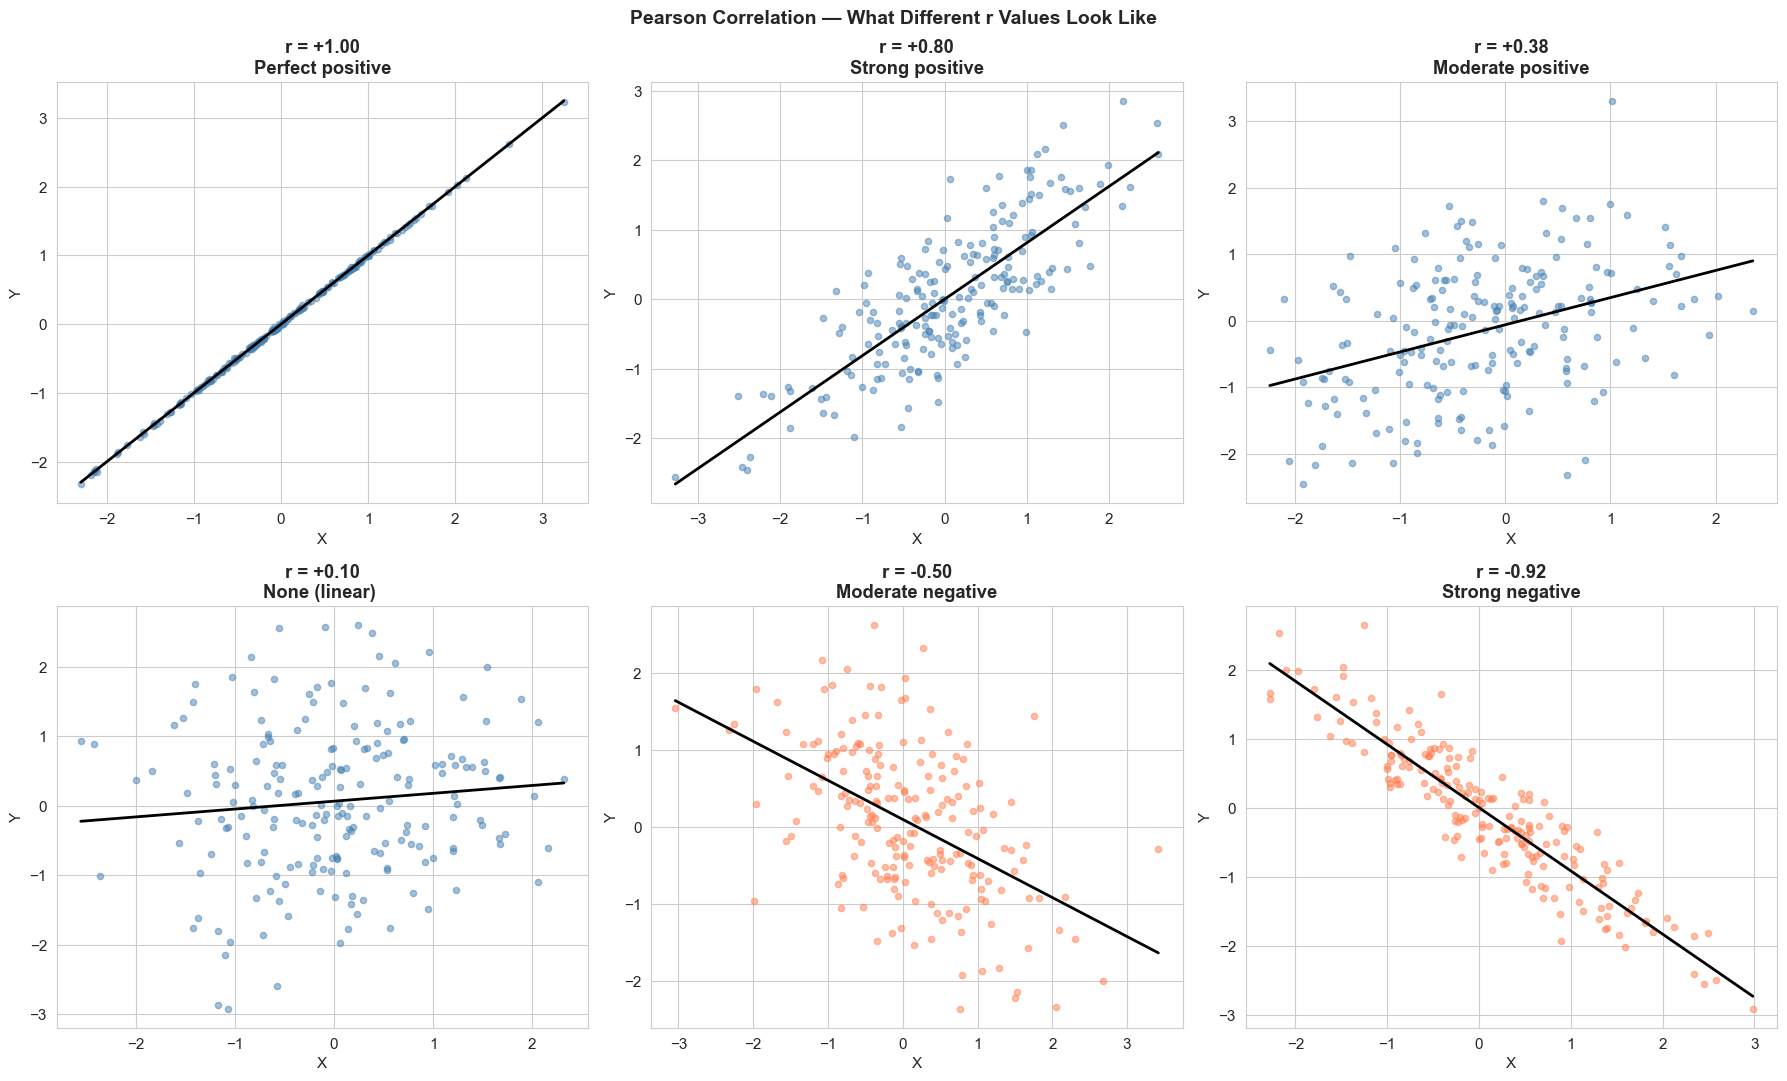

In [7]:
# ── Correlation: Visual Gallery of Different r Values ─────────────────────
# Each panel: synthetic (X,Y) from a bivariate normal with correlation r.
np.random.seed(SEED)

def make_correlated(r, n=200):
    """Generate bivariate data with a target Pearson r."""
    cov = [[1, r], [r, 1]]
    data = np.random.multivariate_normal([0, 0], cov, n)
    return data[:, 0], data[:, 1]

r_values   = [1.0, 0.8, 0.5, 0.0, -0.5, -0.9]
fig, axes  = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, r_target in zip(axes, r_values):
    r_use = 0.9999 if r_target == 1.0 else r_target
    x, y = make_correlated(r_use)
    actual_r, p = stats.pearsonr(x, y)

    colour = 'steelblue' if r_target >= 0 else 'coral'
    ax.scatter(x, y, alpha=0.5, s=20, color=colour)

    # Trend line
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m*x_line + b, 'k-', linewidth=2)

    strength = (
        'Perfect' if abs(r_target) >= 0.99
        else 'Strong' if abs(r_target) >= 0.7
        else 'Moderate' if abs(r_target) >= 0.4
        else 'None (linear)'
    )
    direction = 'positive' if r_target > 0 else 'negative' if r_target < 0 else ''
    ax.set_title(f'r = {actual_r:+.2f}\n{strength} {direction}', fontweight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.suptitle('Pearson Correlation — What Different r Values Look Like',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

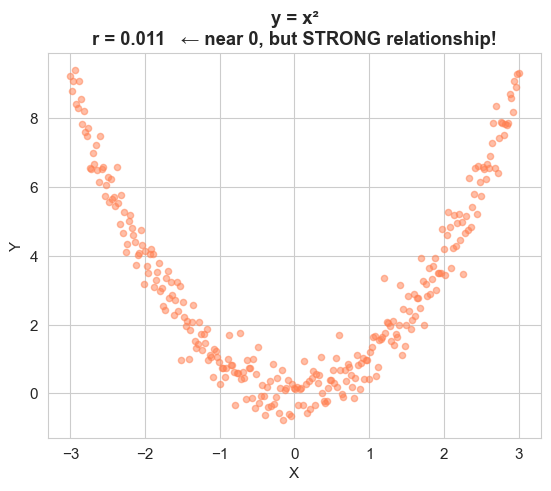

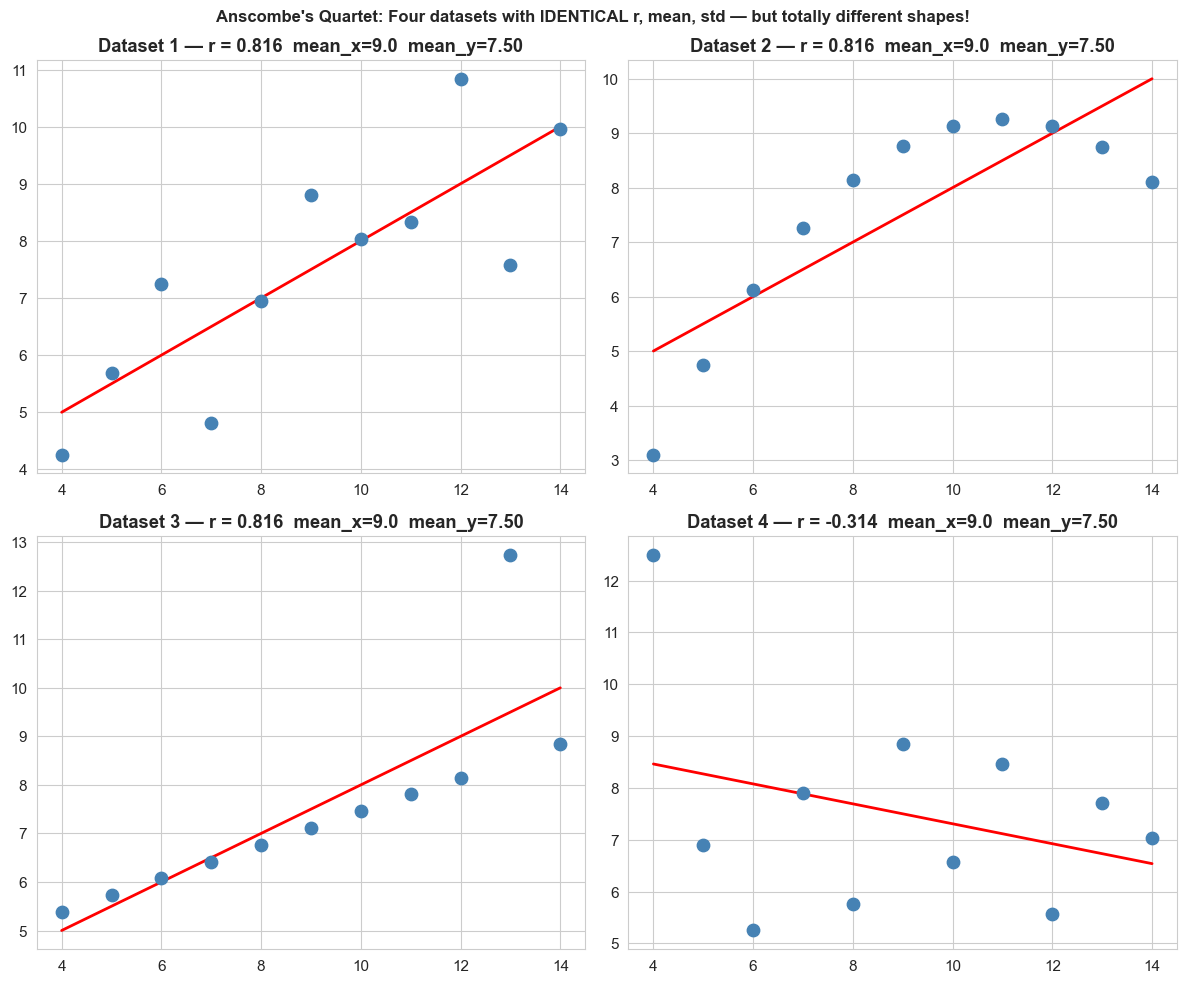

Lesson: ALWAYS visualise your data. r alone is never enough.
Anscombe's Quartet: same mean, same std, same r = 0.816, but very different data.
→ Always pair correlation analysis with scatter plots.


In [8]:
# ── The Correlation Trap: r=0 does NOT mean no relationship ───────────────
np.random.seed(SEED)
x_nl = np.linspace(-3, 3, 300)
y_nl = x_nl ** 2 + np.random.normal(0, 0.5, 300)  # Perfect U-shape

r_nl, p_nl = stats.pearsonr(x_nl, y_nl)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(x_nl, y_nl, alpha=0.5, color='coral', s=20)
axes[0].set_title(f'y = x²\nr = {r_nl:.3f}   ← near 0, but STRONG relationship!',
                   fontweight='bold')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

# Anscombe's Quartet — famous example
anscombe = {
    'x': [10,8,13,9,11,14,6,4,12,7,5],
    'y1':[8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68],
    'y2':[9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74],
    'y3':[7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73],
    'y4':[6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.50,5.56,7.91,6.89]
}

axes[1].set_visible(False)
fig2, ax2 = plt.subplots(2, 2, figsize=(12, 10))
ax2 = ax2.flatten()
for i, y_key in enumerate(['y1','y2','y3','y4']):
    x_a = anscombe['x']
    y_a = anscombe[y_key]
    r_a, _ = stats.pearsonr(x_a, y_a)
    ax2[i].scatter(x_a, y_a, color='steelblue', s=80, zorder=3)
    m, b = np.polyfit(x_a, y_a, 1)
    x_fit = np.linspace(min(x_a), max(x_a), 100)
    ax2[i].plot(x_fit, m*x_fit + b, 'r-', linewidth=2)
    ax2[i].set_title(f"Dataset {i+1} — r = {r_a:.3f}  mean_x={np.mean(x_a):.1f}  mean_y={np.mean(y_a):.2f}",
                     fontweight='bold')

plt.suptitle("Anscombe's Quartet: Four datasets with IDENTICAL r, mean, std — but totally different shapes!",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Lesson: ALWAYS visualise your data. r alone is never enough.')
print('Anscombe\'s Quartet: same mean, same std, same r = 0.816, but very different data.')
print('→ Always pair correlation analysis with scatter plots.')

---
# 9. Outliers

## What question does it answer?
> *"Are there any data points so extreme that they are probably errors, or rare events that will distort my model?"*

## Why outliers matter in ML

| Model | Sensitivity to outliers |
|---|---|
| **Linear Regression (OLS)** | Very sensitive — pulls the regression line toward them |
| **Mean / StandardScaler** | Sensitive — outliers inflate mean and std |
| **KNN** | Sensitive — outliers become incorrect nearest neighbours |
| **Decision Trees / Random Forest** | Reasonably robust |

## Two detection methods

### Method 1: Z-score (best for approximately normal data)
Flag a value as an outlier if **|Z| > 3**.
Weakness: mean and std are themselves inflated by outliers — slightly circular.

### Method 2: IQR Fence (best for skewed data — more robust)
$$\text{Lower fence} = Q1 - 1.5 \times IQR \qquad \text{Upper fence} = Q3 + 1.5 \times IQR$$

## What to do with outliers

| Action | When to use |
|---|---|
| **Investigate first** | Always — is it a data entry error or a genuine extreme value? |
| **Remove** | Only if confirmed data error |
| **Cap / Winsorise** | Replace with fence value — preserves the row |
| **Log transform** | Compresses the scale, reduces outlier impact |
| **Use robust models** | Tree-based models, RobustScaler, median-based metrics |

In [ ]:
# ── Outlier Detection: Z-score vs IQR ────────────────────────────────────
np.random.seed(SEED)
salaries = np.concatenate([
    np.random.normal(40000, 8000, 97),
    [150000, 200000, -5000]
])

z_scores     = np.abs(stats.zscore(salaries))
z_outliers   = salaries[z_scores > 3]
Q1_s, Q3_s   = np.percentile(salaries, [25, 75])
IQR_s        = Q3_s - Q1_s
lower, upper = Q1_s - 1.5*IQR_s, Q3_s + 1.5*IQR_s
iqr_outliers = salaries[(salaries < lower) | (salaries > upper)]

print('=== Outlier Detection ===')
print(f'Z-score (|Z|>3) found : {sorted(z_outliers.astype(int))}')
print(f'IQR fence found       : {sorted(iqr_outliers.astype(int))}')
print(f'Fences                : lower={lower:.0f}  upper={upper:.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(salaries, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Original Salary Data', fontweight='bold')
axes[0].set_xlabel('Salary (GBP)')

axes[1].hist(salaries, bins=30, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].axvline(lower, color='crimson', lw=2, linestyle='--', label=f'Lower fence={lower:.0f}')
axes[1].axvline(upper, color='crimson', lw=2, linestyle='--', label=f'Upper fence={upper:.0f}')
axes[1].set_title('IQR Fence Method', fontweight='bold')
axes[1].set_xlabel('Salary (GBP)'); axes[1].legend()
plt.suptitle('Two Methods for Outlier Detection', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

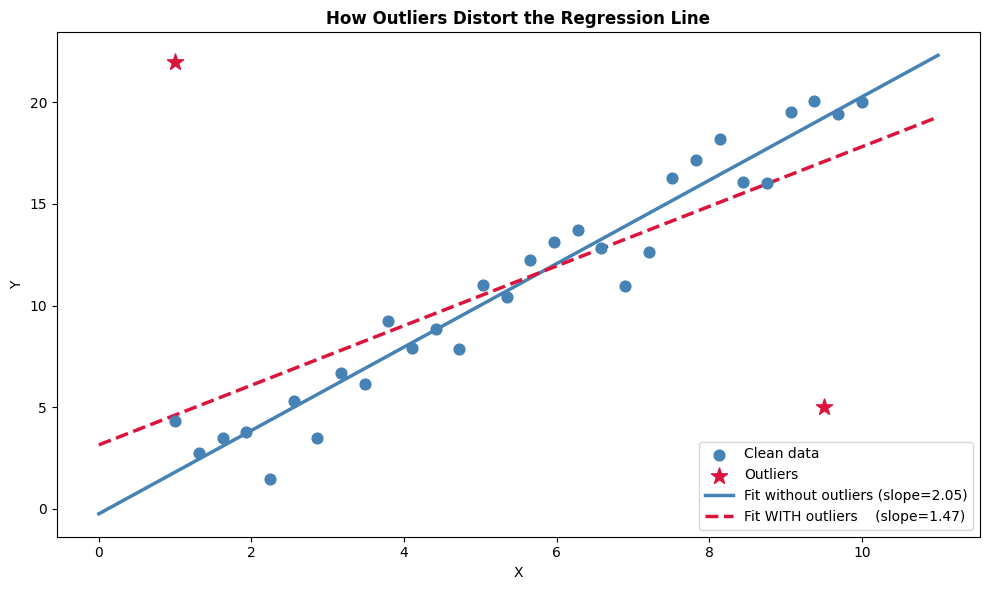

Slope without outliers : 2.052
Slope WITH outliers    : 1.467  (difference = 0.585)

Just two outliers noticeably shifted the slope.
-> Always check for outliers BEFORE fitting a linear model.


In [9]:
# ── How outliers distort the regression line ─────────────────────────────
np.random.seed(SEED)
x_clean = np.linspace(1, 10, 30)
y_clean = 2 * x_clean + np.random.normal(0, 1.5, 30)
x_out   = np.append(x_clean, [9.5, 1.0])
y_out   = np.append(y_clean, [5.0, 22.0])

m_c, b_c = np.polyfit(x_clean, y_clean, 1)
m_o, b_o = np.polyfit(x_out,   y_out,   1)
x_line   = np.linspace(0, 11, 100)

plt.figure(figsize=(10, 6))
plt.scatter(x_clean, y_clean, color='steelblue', s=60, zorder=3, label='Clean data')
plt.scatter([9.5, 1.0], [5.0, 22.0], color='crimson', s=150, marker='*',
            zorder=4, label='Outliers')
plt.plot(x_line, m_c*x_line + b_c, 'steelblue', lw=2.5,
         label=f'Fit without outliers (slope={m_c:.2f})')
plt.plot(x_line, m_o*x_line + b_o, 'crimson', lw=2.5, linestyle='--',
         label=f'Fit WITH outliers    (slope={m_o:.2f})')
plt.xlabel('X'); plt.ylabel('Y')
plt.title('How Outliers Distort the Regression Line', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

print(f'Slope without outliers : {m_c:.3f}')
print(f'Slope WITH outliers    : {m_o:.3f}  (difference = {abs(m_c-m_o):.3f})')
print()
print('Just two outliers noticeably shifted the slope.')
print('-> Always check for outliers BEFORE fitting a linear model.')

---
# 10. Feature Scaling

## What question does it answer?
> *"My features are on completely different scales (age in years vs salary in thousands). Does that matter, and what should I do?"*

## Why scaling matters

| Model type | Needs scaling? | Why |
|---|---|---|
| **Linear / Logistic Regression (regularised)** | Yes | Regularisation penalises large coefficients — unfair across different scales |
| **KNN, K-Means** | Yes | Distance calculations dominated by large-scale features |
| **Neural Networks** | Yes | Gradient descent converges much faster with scaled features |
| **SVM** | Yes | Kernel functions depend on distances |
| **Decision Trees / Random Forest** | No | Split rules are scale-invariant |
| **OLS Linear Regression (no regularisation)** | No | Coefficients adjust automatically |

## Three scalers — when to use which

| Scaler | Formula | When to use | Sensitive to outliers? |
|---|---|---|---|
| **StandardScaler** | $z = (x - \mu) / \sigma$ | Default choice, roughly normal data | Yes |
| **MinMaxScaler** | $z = (x - x_{min}) / (x_{max} - x_{min})$ | Need values in [0, 1], no outliers | Very yes |
| **RobustScaler** | $z = (x - Q2) / IQR$ | Outliers present that cannot be removed | No |

In [10]:
# ── Feature Scaling: Dummy Example ────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Five students: Age (22-45), Salary in GBPk (28-90), Hours studied (3-8)
data_raw   = np.array([[22,28,5],[35,55,8],[28,40,3],[45,90,6],[30,48,7]], dtype=float)
feat_names = ['Age', 'Salary(k)', 'Hours']
df_raw     = pd.DataFrame(data_raw, columns=feat_names)

print('=== Original Data ===')
print(df_raw.to_string(index=False))
print()
print('Feature ranges:')
for col in feat_names:
    r = df_raw[col].max() - df_raw[col].min()
    print(f'  {col:<15} min={df_raw[col].min():.0f}  max={df_raw[col].max():.0f}  range={r:.0f}')
print()
print('Problem: Salary range (62) >> Age range (23) >> Hours range (5).')
print('A KNN model would almost ignore Hours and over-weight Salary.')
print('-> We must scale so all features contribute fairly.')

=== Original Data ===
 Age  Salary(k)  Hours
22.0       28.0    5.0
35.0       55.0    8.0
28.0       40.0    3.0
45.0       90.0    6.0
30.0       48.0    7.0

Feature ranges:
  Age             min=22  max=45  range=23
  Salary(k)       min=28  max=90  range=62
  Hours           min=3  max=8  range=5

Problem: Salary range (62) >> Age range (23) >> Hours range (5).
A KNN model would almost ignore Hours and over-weight Salary.
-> We must scale so all features contribute fairly.


In [11]:
# ── Apply all three scalers and compare ───────────────────────────────────
print('=== Scaled Results ===')
print()
for name, scaler in [('StandardScaler  (mean=0, std=1)',   StandardScaler()),
                      ('MinMaxScaler    (range 0 to 1)',    MinMaxScaler()),
                      ('RobustScaler    (median=0, IQR=1)', RobustScaler())]:
    scaled = scaler.fit_transform(data_raw)
    df_s   = pd.DataFrame(scaled, columns=feat_names)
    ranges = {c: round(df_s[c].max()-df_s[c].min(), 3) for c in feat_names}
    print(f'--- {name} ---')
    print(df_s.round(3).to_string(index=False))
    print(f'  Ranges: {ranges}')
    print()

print('After scaling all features are on comparable ranges.')
print('Now a KNN model treats Age, Salary, and Hours equally.')

=== Scaled Results ===

--- StandardScaler  (mean=0, std=1) ---
   Age  Salary(k)  Hours
-1.295     -1.157 -0.465
 0.389      0.134  1.279
-0.518     -0.583 -1.627
 1.684      1.807  0.116
-0.259     -0.201  0.697
  Ranges: {'Age': np.float64(2.979), 'Salary(k)': np.float64(2.963), 'Hours': np.float64(2.906)}

--- MinMaxScaler    (range 0 to 1) ---
  Age  Salary(k)  Hours
0.000      0.000    0.4
0.565      0.435    1.0
0.261      0.194    0.0
1.000      1.000    0.6
0.348      0.323    0.8
  Ranges: {'Age': np.float64(1.0), 'Salary(k)': np.float64(1.0), 'Hours': np.float64(1.0)}

--- RobustScaler    (median=0, IQR=1) ---
   Age  Salary(k)  Hours
-1.143     -1.333   -0.5
 0.714      0.467    1.0
-0.286     -0.533   -1.5
 2.143      2.800    0.0
 0.000      0.000    0.5
  Ranges: {'Age': np.float64(3.286), 'Salary(k)': np.float64(4.133), 'Hours': np.float64(2.5)}

After scaling all features are on comparable ranges.
Now a KNN model treats Age, Salary, and Hours equally.


In [12]:
# ── Why RobustScaler exists: outlier problem with MinMax ─────────────────
data_ceo = data_raw.copy()
data_ceo[2, 1] = 500   # Student 3 earns 500k GBP

print('Data with outlier (Student 3 salary = 500k):')
print(pd.DataFrame(data_ceo, columns=feat_names).to_string(index=False))
print()
results = {}
for name, scaler in [('StandardScaler', StandardScaler()),
                      ('MinMaxScaler',   MinMaxScaler()),
                      ('RobustScaler',   RobustScaler())]:
    results[name] = scaler.fit_transform(data_ceo)[:, 1]   # salary column only

print(f'{"Student":<12}', end='')
for name in results:
    print(f'{name:<20}', end='')
print()
print('-' * 72)
for i in range(5):
    print(f'{"Student "+str(i+1):<12}', end='')
    for vals in results.values():
        print(f'{vals[i]:<20.3f}', end='')
    print()

print()
print('MinMaxScaler  : normal students crushed to 0.00-0.09 range -> almost useless!')
print('StandardScaler: normal students compressed; variance dominated by outlier')
print('RobustScaler  : normal students spread meaningfully; outlier is just large')
print()
print('Decision rules:')
print('  Roughly normal, no outliers  -> StandardScaler')
print('  Outliers present             -> RobustScaler')
print('  Must be 0-1 range, clean data -> MinMaxScaler')
print()
print('CRITICAL RULE: Always fit the scaler on TRAINING data only.')
print('  WRONG  -> scaler.fit(X_all)       # leaks test data statistics')
print('  CORRECT-> scaler.fit(X_train)     # learns from training only')
print('  BEST   -> use a Pipeline (handles this automatically)')

Data with outlier (Student 3 salary = 500k):
 Age  Salary(k)  Hours
22.0       28.0    5.0
35.0       55.0    8.0
28.0      500.0    3.0
45.0       90.0    6.0
30.0       48.0    7.0

Student     StandardScaler      MinMaxScaler        RobustScaler        
------------------------------------------------------------------------
Student 1   -0.649              0.000               -0.643              
Student 2   -0.498              0.057               0.000               
Student 3   1.987               1.000               10.595              
Student 4   -0.303              0.131               0.833               
Student 5   -0.537              0.042               -0.167              

MinMaxScaler  : normal students crushed to 0.00-0.09 range -> almost useless!
StandardScaler: normal students compressed; variance dominated by outlier
RobustScaler  : normal students spread meaningfully; outlier is just large

Decision rules:
  Roughly normal, no outliers  -> StandardScaler
  Outliers 

---
# 11. All Together — Quick Reference

You have now covered location, spread, normal, shape, relationships (covariance & correlation), outliers, and scaling. Use the table as a **memory aid** and the checklist before every model.

## Putting it all together: what each statistic tells you

| Statistic | Question it answers | ML relevance |
|---|---|---|
| **Mean** | Where is the centre? | Imputation, baseline, loss functions |
| **Variance / Std** | How spread out? | Scaling, noise, bias-variance |
| **Q1 / Q2 / Q3** | Where are the boundaries of each 25%? | Robust stats, outlier detection |
| **Skewness** | Is the distribution symmetric or tail-heavy? | Transformation decisions |
| **Kurtosis** | How heavy are the tails vs normal? | Outlier risk, normality check |
| **Correlation (r)** | Do X and Y move together linearly? | Feature selection, multicollinearity |
| **p-value** | Could this be a fluke if H₀ were true? | Feature significance, assumption tests |

## The EDA checklist: what to compute and check for every feature

```
For each feature:
  1. Mean and Median          → Are they similar? (If not, skewed)
  2. Std and IQR              → How spread out? Any extreme range?
  3. Min, Max                 → Any impossible values?
  4. Q1, Q3, IQR fences       → Flag outliers beyond Q3 + 1.5×IQR
  5. Skewness                 → |skew| > 1 → consider log/sqrt transform
  6. Kurtosis                 → High excess kurtosis → more outliers to handle
  7. Correlation with target  → |r| > 0.1 → potentially useful predictor
  8. Correlation with other   → |r| > 0.7 → multicollinearity risk
  9. p-value (in regression)  → p < 0.05 → feature is statistically significant
```

In [4]:
# ── Comprehensive EDA Function — All Stats in One Table ───────────────────
def full_eda(df, target_col=None):
    """
    Run comprehensive EDA on all numeric columns.
    If target_col is provided, include correlation with target.
    """
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    if target_col and target_col in numeric_cols:
        feature_cols = [c for c in numeric_cols if c != target_col]
    else:
        feature_cols = numeric_cols

    rows = []
    for col in feature_cols:
        data = df[col].dropna()
        q1, q2, q3 = np.percentile(data, [25, 50, 75])
        iqr  = q3 - q1
        n_out = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()

        row = {
            'Feature'      : col,
            'n'            : len(data),
            'Missing %'    : round((df[col].isna().sum() / len(df)) * 100, 1),
            'Mean'         : round(data.mean(), 3),
            'Median'       : round(data.median(), 3),
            'Std'          : round(data.std(), 3),
            'Q1'           : round(q1, 3),
            'Q3'           : round(q3, 3),
            'IQR'          : round(iqr, 3),
            'Skewness'     : round(stats.skew(data), 3),
            'Kurtosis'     : round(stats.kurtosis(data), 3),
            'Outliers (IQR)': n_out
        }

        if target_col and target_col in df.columns:
            target_data = df[target_col]
            common_idx  = df[[col, target_col]].dropna().index
            r, p        = stats.pearsonr(df.loc[common_idx, col],
                                          df.loc[common_idx, target_col])
            row['r with target'] = round(r, 3)
            row['p-value']       = round(p, 4)

        rows.append(row)

    result = pd.DataFrame(rows).set_index('Feature')
    return result


# ── Demo on California Housing ─────────────────────────────────────────────
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
df_demo = housing.frame

eda_result = full_eda(df_demo, target_col='MedHouseVal')

print('=== Comprehensive EDA — California Housing ===')
print(eda_result.to_string())
print()
print('How to read this table:')
print('  Skewness > 1     → highly right-skewed → log transform candidate')
print('  Kurtosis > 3     → fat tails → more outliers than expected')
print('  |r| > 0.4        → moderate-to-strong linear predictor')
print('  p-value < 0.05   → statistically significant correlation with target')
print('  Outliers (IQR) % → if > 5% of rows, outlier strategy needed')

=== Comprehensive EDA — California Housing ===
                n  Missing %      Mean    Median       Std       Q1        Q3      IQR  Skewness   Kurtosis  Outliers (IQR)  r with target  p-value
Feature                                                                                                                                            
MedInc      20640        0.0     3.871     3.535     1.900    2.563     4.743    2.180     1.647      4.951             681          0.688   0.0000
HouseAge    20640        0.0    28.639    29.000    12.586   18.000    37.000   19.000     0.060     -0.801               0          0.106   0.0000
AveRooms    20640        0.0     5.429     5.229     2.474    4.441     6.052    1.612    20.696    879.140             511          0.152   0.0000
AveBedrms   20640        0.0     1.097     1.049     0.474    1.006     1.100    0.093    31.315   1636.315            1424         -0.047   0.0000
Population  20640        0.0  1425.477  1166.000  1132.462  787.0

---
# 12. p-value

## What question does it answer?
> *"If there were truly NO effect (no relationship, no difference), how likely is it that I'd see data at least as extreme as what I observed — just by chance?"*

## The formal definition

The p-value is the **probability of observing your test statistic (or something more extreme) assuming the null hypothesis is true**.

| Term | Meaning |
|---|---|
| **Null hypothesis (H₀)** | The boring claim — "there is no effect / no difference" |
| **Alternative hypothesis (H₁)** | What you're trying to show — "there IS an effect" |
| **Test statistic** | A number computed from your data that measures how far from H₀ you are |
| **p-value** | P(test statistic this extreme \| H₀ is true) |
| **α (significance level)** | Threshold — usually 0.05. If p < α, reject H₀. |

## How to interpret it

| p-value | Interpretation |
|---|---|
| p < 0.001 | Very strong evidence against H₀ |
| p < 0.01 | Strong evidence against H₀ |
| p < 0.05 | Moderate evidence — conventionally "statistically significant" |
| p ≥ 0.05 | Insufficient evidence to reject H₀ |
| p ≥ 0.10 | Little to no evidence against H₀ |

## What the p-value is NOT

This is one of the most misunderstood concepts in statistics:

| Misconception | Truth |
|---|---|
| "p = 0.03 means there's a 3% chance H₀ is true" |  Wrong. It means: IF H₀ were true, you'd see this data only 3% of the time |
| "p < 0.05 means the effect is large" |  Wrong. Statistical significance ≠ practical significance |
| "p > 0.05 proves there's no effect" |  Wrong. It just means you lack evidence to reject H₀ |
| "p < 0.05 means the result will replicate" |  Wrong. It can still be a false positive |

## Why it matters in ML

| Use case | How p-value is used |
|---|---|
| **Regression coefficients** | p < 0.05 for a feature's coefficient → evidence it has a real effect |
| **Feature selection** | Drop features with p >> 0.05 in the statsmodels summary |
| **Normality tests** | Shapiro-Wilk p > 0.05 → residuals are consistent with normality |
| **Homoscedasticity test** | Breusch-Pagan p < 0.05 → heteroscedasticity detected |
| **Model comparison** | F-test p-value → model is better than predicting the mean |

In [ ]:
# ── p-value: Building intuition with a coin flip ──────────────────────────
# Toy problem; same logic scales to regression p-values later.
# Scenario: You suspect a coin is biased. You flip it 20 times and get 15 heads.
#           H₀: coin is fair (p_heads = 0.5)
#           H₁: coin is biased (p_heads ≠ 0.5)

from scipy.stats import binom

n_flips  = 20
observed = 15   # heads
p_fair   = 0.5

# p-value: probability of getting 15 OR MORE heads if coin is fair
p_value_one_tail = 1 - binom.cdf(observed - 1, n_flips, p_fair)
p_value_two_tail = 2 * p_value_one_tail  # two-sided test

print('=== Coin Flip Hypothesis Test ===')
print(f'Observed heads  : {observed}/{n_flips}')
print(f'H₀              : coin is fair (p_heads = 0.5)')
print(f'p-value (1-tail): {p_value_one_tail:.4f}')
print(f'p-value (2-tail): {p_value_two_tail:.4f}')
print()
if p_value_two_tail < 0.05:
    print(f'p = {p_value_two_tail:.4f} < 0.05 → REJECT H₀')
    print('Conclusion: Evidence that the coin is biased.')
else:
    print(f'p = {p_value_two_tail:.4f} ≥ 0.05 → FAIL TO REJECT H₀')
    print('Conclusion: Insufficient evidence to say the coin is biased.')

In [ ]:
# ── Visualise p-value as an area under the distribution ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Discrete binomial — coin flip
k_values  = np.arange(0, n_flips + 1)
probs     = binom.pmf(k_values, n_flips, p_fair)
colours_k = ['crimson' if k >= observed else 'steelblue' for k in k_values]

axes[0].bar(k_values, probs, color=colours_k, edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Number of Heads')
axes[0].set_ylabel('Probability')
axes[0].set_title(
    f'Coin Flip: H₀ Distribution (Binomial, p=0.5, n=20)\n'
    f'Red area = P(heads ≥ {observed} | fair coin) = {p_value_one_tail:.4f}',
    fontweight='bold'
)
axes[0].axvline(observed, color='crimson', linestyle='--', linewidth=2,
                label=f'Observed = {observed}')
axes[0].legend()

p_patch = mpatches.Patch(color='crimson', alpha=0.8,
                          label=f'p-value region = {p_value_one_tail:.4f}')
axes[0].legend(handles=[p_patch])

# Right: Continuous normal — t-test intuition
# H₀: mean exam score = 70  |  Observed sample mean = 76 (n=30, std=10)
sample_mean = 76
null_mean   = 70
sample_std  = 10
sample_n    = 30
se          = sample_std / np.sqrt(sample_n)
t_stat      = (sample_mean - null_mean) / se
p_t         = 2 * (1 - stats.t.cdf(abs(t_stat), df=sample_n-1))

x_t = np.linspace(-4.5, 4.5, 400)
y_t = stats.t.pdf(x_t, df=sample_n - 1)

axes[1].plot(x_t, y_t, 'steelblue', linewidth=2, label='t-distribution (H₀)')
axes[1].fill_between(x_t, y_t, where=(x_t >= abs(t_stat)), color='crimson', alpha=0.5,
                      label=f'Right tail (t≥{t_stat:.2f})')
axes[1].fill_between(x_t, y_t, where=(x_t <= -abs(t_stat)), color='crimson', alpha=0.5,
                      label='Left tail (symmetric)')
axes[1].axvline(t_stat, color='crimson', linestyle='--', linewidth=2)
axes[1].axvline(-t_stat, color='crimson', linestyle='--', linewidth=2)
axes[1].set_xlabel('t-statistic')
axes[1].set_ylabel('Density')
axes[1].set_title(
    f'Two-sided t-test: H₀: μ=70, observed mean=76\n'
    f't-stat={t_stat:.2f},  p-value={p_t:.4f}  →  {"Reject H₀" if p_t < 0.05 else "Fail to Reject H₀"}',
    fontweight='bold'
)
axes[1].legend(fontsize=9)

plt.suptitle('p-value = the RED AREA — Probability of data this extreme under H₀',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Exam t-test: sample mean=76 vs H₀ mean=70')
print(f'  t-statistic = {t_stat:.3f}')
print(f'  p-value     = {p_t:.4f}')
print(f'  → {"REJECT H₀: the class performed significantly above 70" if p_t < 0.05 else "Cannot reject H₀"}')

In [ ]:
# ── p-value in Regression Context ─────────────────────────────────────────
# Three features: one strongly related, one weakly related, one pure noise
import statsmodels.api as sm

np.random.seed(SEED)
n = 150

useful_feature  = np.random.normal(0, 1, n)           # Strong effect
weak_feature    = np.random.normal(0, 1, n)           # Small effect
noise_feature   = np.random.normal(0, 1, n)           # No real effect

y_reg = 3.0 * useful_feature + 0.3 * weak_feature + 0 * noise_feature \
        + np.random.normal(0, 1, n)

X_reg = pd.DataFrame({
    'strong_feature': useful_feature,
    'weak_feature'  : weak_feature,
    'noise_feature' : noise_feature
})

X_with_const = sm.add_constant(X_reg)
model_pval = sm.OLS(y_reg, X_with_const).fit()

print(model_pval.summary())
print()
print('=== Reading the p-values ===')
for feat, pval in zip(['strong_feature','weak_feature','noise_feature'],
                       model_pval.pvalues[1:]):
    decision = 'KEEP — significant' if pval < 0.05 else 'CONSIDER REMOVING — not significant'
    print(f'  {feat:<20}  p = {pval:.4f}  → {decision}')

In [ ]:
# ── p-value and Sample Size: a critical interaction ───────────────────────
#
# With enough data, even TINY real effects become statistically significant.
# This is why p < 0.05 is NOT the same as "large" or "important" effect.

np.random.seed(SEED)
sample_sizes = [10, 30, 100, 500, 2000, 10000]
true_effect  = 0.15   # Small but real: X increases y by 0.15 units

p_values_by_n = []
for n_s in sample_sizes:
    x_s   = np.random.normal(0, 1, n_s)
    y_s   = true_effect * x_s + np.random.normal(0, 1, n_s)
    _, p_s = stats.pearsonr(x_s, y_s)
    p_values_by_n.append(p_s)

plt.figure(figsize=(10, 5))
colours_n = ['crimson' if p < 0.05 else 'steelblue' for p in p_values_by_n]
plt.bar([str(n) for n in sample_sizes], p_values_by_n, color=colours_n, edgecolor='white', alpha=0.8)
plt.axhline(0.05, color='orange', linestyle='--', linewidth=2, label='α = 0.05 threshold')
plt.xlabel('Sample Size')
plt.ylabel('p-value')
plt.title(
    f'Same True Effect (r≈{true_effect}) — Different p-values by Sample Size\n'
    'Red bars = statistically significant at α=0.05',
    fontweight='bold'
)
plt.legend()
plt.tight_layout()
plt.show()

print('Key lesson:')
print(f'  True underlying effect: r ≈ {true_effect} (small but real)')
for n_s, p in zip(sample_sizes, p_values_by_n):
    sig = 'significant' if p < 0.05 else 'NOT significant'
    print(f'  n={n_s:>6}  p={p:.4f}  → {sig}')
print()
print('With n=10000, a trivially small effect looks very significant.')
print('→ Always report EFFECT SIZE (r, R², Cohen\'s d) alongside p-value.')
print('→ Ask: "Is this effect *practically* meaningful?" — not just "Is p < 0.05?"')

---
# 13. Confidence Intervals

## What question does it answer?
> *"I calculated the mean (or a coefficient) from my sample. Where does the true population value probably lie?"*

## The key idea

Any statistic from a sample is an **estimate** — slightly different each time you sample.
A confidence interval gives a **range of plausible values** for the true population parameter.

## The formula (for a mean)

$$\text{CI} = \bar{x} \pm t_{\alpha/2} \cdot \frac{s}{\sqrt{n}}$$

| Term | Meaning |
|---|---|
| $\bar{x}$ | Sample mean |
| $t_{\alpha/2}$ | Critical t-value (~1.96 for 95% CI with large n) |
| $s / \sqrt{n}$ | **Standard error** — how much the sample mean varies across samples |

## Correct interpretation

> *"If I repeated this study 100 times, approximately 95 of the resulting CIs would contain the true population mean."*

**NOT**: "There is a 95% chance the true mean is in this interval." (The true mean is fixed.)

## Why it matters in ML

| Use case | How CI is used |
|---|---|
| **Regression coefficients** | statsmodels 95% CI — if it crosses 0, the feature may not matter |
| **Model evaluation** | Report RMSE with a CI, not just a single number |
| **A/B testing** | Tells you whether a difference is practically meaningful |

In [ ]:
# ── Confidence Interval: built from scratch ──────────────────────────────
import matplotlib.patches as mpatches

# 40 cereal boxes measured. Target weight = 500g. Is the machine underfilling?
np.random.seed(SEED)
sample   = np.random.normal(498, 10, 40)   # true mean = 498g
n        = len(sample)
x_bar    = sample.mean()
s        = sample.std(ddof=1)
se       = s / np.sqrt(n)
t_crit   = stats.t.ppf(0.975, df=n-1)
ci_lower = x_bar - t_crit * se
ci_upper = x_bar + t_crit * se

print('=== 95% Confidence Interval for Mean Box Weight ===')
print(f'Sample size      : {n}')
print(f'Sample mean      : {x_bar:.2f}g')
print(f'Standard error   : {se:.2f}g   (= std / sqrt(n))')
print(f't critical value : {t_crit:.4f}')
print(f'Margin of error  : +/- {t_crit*se:.2f}g')
print(f'95% CI           : [{ci_lower:.2f}g,  {ci_upper:.2f}g]')
print()
if ci_lower <= 500 <= ci_upper:
    print('500g IS inside the CI -> no strong evidence of underfilling at alpha=0.05')
else:
    print('500g is OUTSIDE the CI -> evidence that boxes are underfilled!')
lo, hi = stats.t.interval(0.95, df=n-1, loc=x_bar, scale=se)
print(f'\nScipy shortcut: [{lo:.2f}g,  {hi:.2f}g]  (same answer)')

In [ ]:
# ── What 95% CI really means: 20 repeated samples ────────────────────────
np.random.seed(SEED)
fig, ax = plt.subplots(figsize=(12, 8))
hits = 0
for i in range(20):
    samp  = np.random.normal(500, 10, 40)
    xb    = samp.mean()
    se_i  = samp.std(ddof=1) / np.sqrt(40)
    lo, hi = stats.t.interval(0.95, df=39, loc=xb, scale=se_i)
    covers = lo <= 500 <= hi
    hits  += covers
    c = 'steelblue' if covers else 'crimson'
    ax.plot([lo, hi], [i, i], color=c, linewidth=3, alpha=0.8)
    ax.plot(xb, i, 'o', color=c, markersize=6)

ax.axvline(500, color='black', linestyle='--', linewidth=2, label='True mean = 500')
ax.set_xlabel('Box Weight (g)'); ax.set_ylabel('Sample number')
ax.set_title(
    f'20 samples — each with its own 95% CI\n'
    f'{hits}/20 contain the true mean  (expect ~19/20)',
    fontweight='bold'
)
bp = mpatches.Patch(color='steelblue', label=f'Contains true mean ({hits})')
rp = mpatches.Patch(color='crimson',   label=f'Misses true mean ({20-hits})')
ax.legend(handles=[bp, rp]); plt.tight_layout(); plt.show()

print('This is the true meaning of a 95% CI:')
print('  Over many repetitions, 95% of CIs contain the true value.')
print('  Any single CI either contains it or does not -- we just do not know which.')

---
# 14. Type I and Type II Errors

## What question does it answer?
> *"When I make a decision based on a p-value or a model prediction, what kinds of mistakes can I make?"*

## The two types of error

Think of it like a court verdict — innocent until proven guilty.
- **H0 = innocent** (no effect) | **H1 = guilty** (there is an effect)

| | H0 is actually TRUE | H0 is actually FALSE |
|---|---|---|
| **We REJECT H0** | **Type I Error** (False Positive) — wrongly convict innocent | Correct (True Positive) |
| **We FAIL TO REJECT H0** | Correct (True Negative) | **Type II Error** (False Negative) — let guilty go free |

## Key terms

| Symbol | Name | Meaning |
|---|---|---|
| **alpha** | Significance level | = P(Type I Error) — usually set to 0.05 |
| **beta** | | = P(Type II Error) |
| **Power = 1 - beta** | Statistical power | Probability of correctly detecting a real effect |

## The fundamental tradeoff
> Reducing Type I errors (lower alpha) increases Type II errors. Only more data reduces both.

## Why it matters in ML

| Application | Type I Error cost | Type II Error cost |
|---|---|---|
| **Medical diagnosis** | Healthy patient treated unnecessarily | Sick patient sent home — potentially fatal |
| **Spam filter** | Legitimate email blocked | Spam gets through |
| **Fraud detection** | Genuine transaction blocked | Fraud undetected |

> In classification: Type I = **False Positive**, Type II = **False Negative**.
> **Precision** and **Recall** track these directly.

In [ ]:
# ── Type I & II Error tradeoff: visual ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x      = np.linspace(-5, 8, 500)
null_d = stats.norm(0, 1)
alt_d  = stats.norm(2, 1)

for ax, thr, title in [
    (axes[0], 1.645, 'alpha=0.05 (standard threshold)'),
    (axes[1], 2.326, 'alpha=0.01 (stricter: fewer FP, more FN)'),
]:
    ax.plot(x, null_d.pdf(x), 'steelblue', lw=2.5, label='H0 dist (no effect)')
    ax.plot(x, alt_d.pdf(x),  'coral',     lw=2.5, label='H1 dist (real effect)')
    ax.axvline(thr, color='black', linestyle='--', lw=2, label=f'Threshold={thr}')
    ax.fill_between(x, null_d.pdf(x), where=(x >= thr),
                    color='steelblue', alpha=0.5, label='Type I Error (FP)')
    ax.fill_between(x, alt_d.pdf(x),  where=(x <= thr),
                    color='coral',     alpha=0.5, label='Type II Error (FN)')
    power = 1 - alt_d.cdf(thr)
    ax.set_title(f'{title}\nPower = {power:.1%}', fontweight='bold')
    ax.set_xlabel('Test Statistic'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Type I vs Type II Error Tradeoff\n'
             'Stricter alpha -> fewer FP but more FN',
             fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

print('Moving threshold RIGHT -> fewer Type I, more Type II.')
print('Moving threshold LEFT  -> fewer Type II, more Type I.')
print('Only way to reduce BOTH simultaneously: collect more data.')

In [5]:
# ── Confusion Matrix: the ML version of the error table ─────────────────
TN, FP, FN, TP = 90, 10, 5, 45   # spam filter on 150 emails

print('=== Spam Filter Confusion Matrix ===')
print()
print(f'                  | Predicted: NOT Spam | Predicted: SPAM')
print(f'  Actual: Legit   |  TN={TN} (correct)     | FP={FP}  (Type I -- blocked legit!)')
print(f'  Actual: Spam    |  FN={FN}  (Type II)     | TP={TP} (correct)')
print()

accuracy  = (TP+TN) / (TP+TN+FP+FN)
precision = TP / (TP+FP)
recall    = TP / (TP+FN)
f1        = 2 * precision * recall / (precision + recall)

print(f'Accuracy   = (TP+TN)/total       = {accuracy:.1%}')
print(f'Precision  = TP/(TP+FP)          = {precision:.1%}  (of flagged spam, how many real?)')
print(f'Recall     = TP/(TP+FN)          = {recall:.1%}  (of all spam, how much caught?)')
print(f'F1 Score   = 2*P*R/(P+R)         = {f1:.1%}  (balances both)')
print()
print('High Recall  = few Type II errors  (important for medical diagnosis)')
print('High Precision = few Type I errors (important for fraud alerts)')
print('Use F1 Score when both matter equally.')

=== Spam Filter Confusion Matrix ===

                  | Predicted: NOT Spam | Predicted: SPAM
  Actual: Legit   |  TN=90 (correct)     | FP=10  (Type I -- blocked legit!)
  Actual: Spam    |  FN=5  (Type II)     | TP=45 (correct)

Accuracy   = (TP+TN)/total       = 90.0%
Precision  = TP/(TP+FP)          = 81.8%  (of flagged spam, how many real?)
Recall     = TP/(TP+FN)          = 90.0%  (of all spam, how much caught?)
F1 Score   = 2*P*R/(P+R)         = 85.7%  (balances both)

High Recall  = few Type II errors  (important for medical diagnosis)
High Precision = few Type I errors (important for fraud alerts)
Use F1 Score when both matter equally.


**Complete Reference — All 14 Topics**

<font color='red'>**How everything connects**</font>

```
YOUR RAW DATA
  |
  |-- DESCRIBE the centre
  |     |-- Mean    (sensitive to outliers)
  |     +-- Median  = Q2 (robust)
  |
  |-- DESCRIBE the spread
  |     |-- Variance / Std    (mean-based, sensitive to outliers)
  |     |-- IQR = Q3 - Q1    (median-based, robust)
  |     +-- Normal distribution -> 68/95/99.7 rule -> Z-scores
  |
  |-- DESCRIBE the shape
  |     |-- Skewness  -> symmetric or tail-heavy? -> log/sqrt transform decision
  |     +-- Kurtosis  -> how extreme are the tails? -> outlier risk
  |
  |-- FIND PROBLEMS
  |     +-- Outliers  -> Z-score (|Z|>3)  or  IQR fence (Q1/Q3 +/-1.5xIQR)
  |                   -> investigate -> cap, remove, or transform
  |
  |-- DESCRIBE RELATIONSHIPS
  |     |-- Covariance    -> direction of co-movement (scale-dependent)
  |     +-- Correlation r -> direction + standardised strength (-1 to +1)
  |
  |-- PREPARE for modelling
  |     +-- Feature Scaling
  |           |-- StandardScaler  -> normal data, most models
  |           |-- MinMaxScaler    -> need 0-1 range, no outliers
  |           +-- RobustScaler    -> outliers present
  |           WARNING: always fit on TRAINING data only
  |
  +-- MAKE and TEST claims
        |-- p-value             -> how surprising is this if H0 is true?
        |-- Confidence Interval -> plausible range for the true value
        +-- Type I / Type II   -> what kind of mistake could I be making?
```

## Quick-lookup decision table

| Situation | What to use |
|---|---|
| Describe centre of skewed feature | **Median** (Q2) |
| Describe centre of symmetric feature | **Mean** |
| Describe spread robustly | **IQR** |
| Detect outliers in normal data | **Z-score** (|Z| > 3) |
| Detect outliers in skewed data | **IQR fence** |
| Decide if feature needs transformation | **Skewness** (|skew| > 1 -> transform) |
| Check for fat-tail / extreme outlier risk | **Kurtosis** (excess > 0 = fat tails) |
| Check if two variables move together | **Correlation** (Pearson r) |
| Scale for KNN, SVM, Neural Network | **StandardScaler** |
| Scale when outliers cannot be removed | **RobustScaler** |
| Need values strictly 0 to 1, clean data | **MinMaxScaler** |
| Test if a regression coefficient is real | **p-value** (< 0.05 -> significant) |
| Estimate range of a true parameter | **Confidence Interval** |
| Understand cost of wrong decisions | **Type I / Type II Error** |

In [11]:
# ── Master EDA Function — all 14 concepts in one table ───────────────────
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.datasets import fetch_california_housing

def full_eda(df, target_col=None):
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    feature_cols = [c for c in numeric_cols if c != target_col] if target_col else numeric_cols
    rows = []
    for col in feature_cols:
        data = df[col].dropna()
        q1, q2, q3  = np.percentile(data, [25, 50, 75])
        iqr          = q3 - q1
        zs           = np.abs(stats.zscore(data))
        n_iqr        = int(((data < q1-1.5*iqr) | (data > q3+1.5*iqr)).sum())
        n_z          = int((zs > 3).sum())
        skew_val     = stats.skew(data)
        kurt_val     = stats.kurtosis(data)
        if n_iqr / len(data) > 0.05:
            rec = 'RobustScaler'
        elif abs(skew_val) > 1:
            rec = 'Log-transform first'
        else:
            rec = 'StandardScaler'
        row = {
            'Feature'    : col,
            'n'          : len(data),
            'Missing%'   : round(df[col].isna().sum()/len(df)*100, 1),
            'Mean'       : round(data.mean(), 3),
            'Median'     : round(q2, 3),
            'Std'        : round(data.std(), 3),
            'Q1'         : round(q1, 3),
            'Q3'         : round(q3, 3),
            'IQR'        : round(iqr, 3),
            'Skewness'   : round(skew_val, 2),
            'Kurtosis'   : round(kurt_val, 2),
            'Out(IQR)'   : n_iqr,
            'Out(Z>3)'   : n_z,
            'Scale rec.' : rec,
        }
        if target_col and target_col in df.columns:
            idx  = df[[col, target_col]].dropna().index
            r, p = stats.pearsonr(df.loc[idx, col], df.loc[idx, target_col])
            row['r w/ target'] = round(r, 3)
            row['p-value']     = round(p, 4)
            row['Sig?']        = 'Yes' if p < 0.05 else 'No'
        rows.append(row)
    return pd.DataFrame(rows).set_index('Feature')

housing = fetch_california_housing(as_frame=True)
print('=== Comprehensive EDA — California Housing ===')
print(full_eda(housing.frame, target_col='MedHouseVal').to_string())


print()
print('Reading guide:')
print('  Skewness > 1   -> log-transform candidate')
print('  Kurtosis > 3   -> fat tails, more outliers than normal')
print('  |r| > 0.4      -> moderate-strong predictor')
print('  p-value < 0.05 -> statistically significant')
print('  Scale rec.     -> suggested scaler before modelling')

=== Comprehensive EDA — California Housing ===
                n  Missing%      Mean    Median       Std       Q1        Q3      IQR  Skewness  Kurtosis  Out(IQR)  Out(Z>3)           Scale rec.  r w/ target  p-value Sig?
Feature                                                                                                                                                                      
MedInc      20640       0.0     3.871     3.535     1.900    2.563     4.743    2.180      1.65      4.95       681       345  Log-transform first        0.688   0.0000  Yes
HouseAge    20640       0.0    28.639    29.000    12.586   18.000    37.000   19.000      0.06     -0.80         0         0       StandardScaler        0.106   0.0000  Yes
AveRooms    20640       0.0     5.429     5.229     2.474    4.441     6.052    1.612     20.70    879.14       511       133  Log-transform first        0.152   0.0000  Yes
AveBedrms   20640       0.0     1.097     1.049     0.474    1.006     1.100    0.0

# Practical Plotting Guide
## Build every chart used in ML — step by step

This section is a **go-to reference** for the plots you will see throughout these notebooks.
Each chart is built in small stages so you can see exactly what each line of code does.

### How to run this section

- **Full path:** run from top (especially **Imports**), then **Plotting setup** (builds `df`).
- **Plotting-only:** run **Plotting setup** first.
- `NameError` for `df`/`SEED` → you skipped setup.

| Chart | When you use it |
|---|---|
| **Histogram** | Distribution of one variable — shape, skewness, spread |
| **Box plot** | Distribution summary — median, IQR, outliers |
| **Scatter plot** | Relationship between two variables |
| **Line plot** | Trends, fitted lines, distributions |
| **Regression line + confidence band** | Show model fit and uncertainty |
| **Heatmap** | Correlation matrix — all pairwise relationships at once |
| **Bar / Horizontal bar** | Compare values across categories or features |
| **Residual plots** | Check model assumptions after fitting |
| **Q-Q plot** | Check whether residuals are normally distributed |

> **Setup rule**: always call `plt.tight_layout()` before `plt.show()` — it prevents labels overlapping.

In [30]:
# ── Plotting setup and shared dummy data ─────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tabulate import tabulate

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)

# Dummy dataset used throughout this section
# Scenario: 80 students — hours studied, exam score, age, anxiety score
n = 80
hours   = np.random.uniform(1, 10, n)
score   = 8 * hours + 25 + np.random.normal(0, 8, n)
score   = np.clip(score, 0, 100)
age     = np.random.normal(21, 2, n)
anxiety = np.random.normal(50, 10, n)

df = pd.DataFrame({
    'hours_studied': hours,
    'exam_score'   : score,
    'age'          : age,
    'anxiety'      : anxiety
})

# print('Dataset shape:', df.shape)
# print(df.describe().round(2))
print(tabulate(df.describe().round(2), headers="keys", tablefmt="pipe", showindex=False, floatfmt=".2f"))

|   hours_studied |   exam_score |   age |   anxiety |
|----------------:|-------------:|------:|----------:|
|           80.00 |        80.00 | 80.00 |     80.00 |
|            5.19 |        65.76 | 21.30 |     49.52 |
|            2.75 |        23.13 |  1.94 |     10.68 |
|            1.05 |        20.99 | 17.79 |     17.59 |
|            2.66 |        47.55 | 19.55 |     43.03 |
|            4.92 |        65.40 | 21.54 |     49.75 |
|            7.68 |        85.90 | 22.34 |     56.66 |
|            9.88 |       100.00 | 28.71 |     73.15 |


In [7]:
from tabulate import tabulate
print(tabulate(df.head(5), headers="keys", tablefmt="pipe", showindex=False, floatfmt=".2f"))

|   hours_studied |   exam_score |   age |   anxiety |
|----------------:|-------------:|------:|----------:|
|            4.37 |        62.62 | 22.63 |     45.15 |
|            9.56 |       100.00 | 18.54 |     50.82 |
|            7.59 |        81.87 | 21.45 |     73.15 |
|            6.39 |        74.62 | 23.61 |     31.33 |
|            2.40 |        35.38 | 17.79 |     56.86 |


---
## 1. Histogram

**Purpose**: Show the distribution of a single numerical variable.

**What to look for**:
- Shape — is it bell-shaped, skewed, bimodal?
- Spread — how wide is the range?
- Outliers — isolated bars far from the bulk

**Key parameters**:

| Parameter | What it controls |
|---|---|
| `bins` | Number of bars. More bins = more detail but noisier. Start with 20–30. |
| `color` | Fill colour of the bars |
| `edgecolor` | Colour of bar borders — `'white'` gives a clean look |
| `alpha` | Transparency (0=invisible, 1=solid). 0.8 works well. |
| `density=True` | Scale y-axis to probability density instead of raw count |

In [ ]:
# ── Histogram: built in 4 steps ──────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Step 1: bare minimum
axes[0].hist(df['exam_score'])
axes[0].set_title('Step 1: Bare minimum\n(default bins, no styling)', fontweight='bold')

# Step 2: add bins and colour
axes[1].hist(df['exam_score'], bins=20, color='steelblue', edgecolor='green')
axes[1].set_title('Step 2: bins=20, colour added', fontweight='bold')

# Step 3: add axis labels and alpha
axes[2].hist(df['exam_score'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[2].set_xlabel('Exam Score')
axes[2].set_ylabel('Number of Students')
axes[2].set_title('Step 3: axis labels + alpha', fontweight='bold')

# Step 4: mean + median vertical lines
axes[3].hist(df['exam_score'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[3].axvline(df['exam_score'].mean(),   color='crimson',      linestyle='--',
                linewidth=2, label=f'Mean={df["exam_score"].mean():.1f}')
axes[3].axvline(df['exam_score'].median(), color='mediumseagreen', linestyle='--',
                linewidth=2, label=f'Median={df["exam_score"].median():.1f}')
axes[3].set_xlabel('Exam Score')
axes[3].set_ylabel('Number of Students')
axes[3].set_title('Step 4: mean + median lines\n(most informative version)', fontweight='bold')
axes[3].legend(fontsize=9)

plt.suptitle('Building a Histogram — Step by Step', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Key decisions: bins, axvline, legend')


---
## 2. Box Plot

**Purpose**: Compact summary of a distribution — median, spread, and outliers in one chart.

**When to use over histogram**: when comparing multiple groups side by side.

**Anatomy reminder**:
```
     |--whisker--|  [  Q1 | median | Q3  ]  |--whisker--|  o outlier
```

| Parameter | What it controls |
|---|---|
| `vert=False` | Horizontal box plot (easier to read long labels) |
| `patch_artist=True` | Lets you fill the box with colour |
| `medianprops` | Style the median line separately |
| `flierprops` | Style the outlier dots |

In [ ]:
# ── Box Plot: built in 3 steps ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Step 1: bare minimum
axes[0].boxplot(df['exam_score'])
axes[0].set_title('Step 1: Bare minimum', fontweight='bold')

# Step 2: coloured box, styled median
axes[1].boxplot(
    df['exam_score'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='crimson', linewidth=2.5),
    flierprops=dict(marker='o', color='orange', markersize=7)
)
axes[1].set_title('Step 2: Colour + styled median + outlier dots', fontweight='bold')
axes[1].set_ylabel('Exam Score')

# Step 3: compare multiple groups side by side
low_hours  = df.loc[df['hours_studied'] < 5,  'exam_score']
high_hours = df.loc[df['hours_studied'] >= 5, 'exam_score']

axes[2].boxplot(
    [low_hours, high_hours],
    labels=['< 5 hours', '>= 5 hours'],
    patch_artist=True,
    boxprops=dict(alpha=0.7),
    medianprops=dict(color='crimson', linewidth=2.5),
    flierprops=dict(marker='o', markersize=7)
)
# Colour each box differently
colours = ['coral', 'steelblue']
for patch, colour in zip(axes[2].patches, colours):
    patch.set_facecolor(colour)

axes[2].set_title('Step 3: Compare two groups', fontweight='bold')
axes[2].set_ylabel('Exam Score')
axes[2].set_xlabel('Study Hours Group')

plt.suptitle('Building a Box Plot — Step by Step', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Key insight: box plot in Step 3 immediately shows that')
print('high-study students score higher AND have less spread.')

---
## 3. Scatter Plot

**Purpose**: Show the relationship between two numerical variables.

**What to look for**:
- Direction — does Y increase or decrease as X increases?
- Strength — are points tightly clustered around a line or spread out?
- Shape — is the relationship linear or curved?
- Outliers — isolated points far from the main cluster

| Parameter | What it controls |
|---|---|
| `alpha` | Transparency — reduce when points overlap heavily |
| `s` | Marker size in points^2 |
| `c` | Colour — can be a single colour or a variable (creates colour scale) |
| `edgecolor` | Border of each point — `'white'` adds clarity |

In [ ]:
# ── Scatter Plot: built in 4 steps ───────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Step 1: bare minimum
axes[0].scatter(df['hours_studied'], df['exam_score'])
axes[0].set_title('Step 1: Bare minimum', fontweight='bold')

# Step 2: add colour, size, transparency
axes[1].scatter(df['hours_studied'], df['exam_score'],
                color='steelblue', s=60, alpha=0.6, edgecolor='white')
axes[1].set_title('Step 2: Colour + size + alpha', fontweight='bold')
axes[1].set_xlabel('Hours Studied')
axes[1].set_ylabel('Exam Score')

# Step 3: add a trend line
axes[2].scatter(df['hours_studied'], df['exam_score'],
                color='steelblue', s=60, alpha=0.6, edgecolor='white')
m, b = np.polyfit(df['hours_studied'], df['exam_score'], 1)  # fit degree-1 polynomial
x_line = np.linspace(df['hours_studied'].min(), df['hours_studied'].max(), 100)
axes[2].plot(x_line, m*x_line + b, color='crimson', linewidth=2.5, label=f'y={m:.1f}x+{b:.1f}')
axes[2].set_xlabel('Hours Studied')
axes[2].set_ylabel('Exam Score')
axes[2].set_title('Step 3: Trend line added\n(np.polyfit)', fontweight='bold')
axes[2].legend(fontsize=9)

# Step 4: colour points by a third variable (anxiety level)
sc = axes[3].scatter(df['hours_studied'], df['exam_score'],
                     c=df['anxiety'], cmap='RdYlGn_r',
                     s=60, alpha=0.8, edgecolor='white')
plt.colorbar(sc, ax=axes[3], label='Anxiety Score')
axes[3].set_xlabel('Hours Studied')
axes[3].set_ylabel('Exam Score')
axes[3].set_title('Step 4: Third variable\nas colour (cmap)', fontweight='bold')

plt.suptitle('Building a Scatter Plot — Step by Step', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('np.polyfit(x, y, deg=1) -> returns [slope, intercept]')
print('Use c=variable + cmap= to show a 3rd dimension on the scatter.')

---
## 4. Line Plot + Shaded Confidence Band

**Purpose**: Show a trend, a fitted model, or a distribution curve.
The **shaded band** (fill_between) is used to show uncertainty — confidence intervals,
prediction intervals, or standard deviation ranges.

| Parameter | What it controls |
|---|---|
| `linewidth` | Thickness of the line |
| `linestyle` | `'-'` solid, `'--'` dashed, `':'` dotted |
| `alpha` on fill | Transparency of the shaded band — 0.2–0.3 keeps it subtle |
| `label` | Text shown in legend |

In [ ]:
# ── Line Plot + Confidence Band: built in 3 steps ────────────────────────
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

x_sorted = np.sort(df['hours_studied'].values)
x_range  = np.linspace(x_sorted.min(), x_sorted.max(), 200)

# Step 1: bare line (fitted values)
m, b = np.polyfit(df['hours_studied'], df['exam_score'], 1)
axes[0].scatter(df['hours_studied'], df['exam_score'],
                color='steelblue', s=40, alpha=0.5)
axes[0].plot(x_range, m*x_range + b, color='crimson', linewidth=2.5)
axes[0].set_title('Step 1: Scatter + fitted line', fontweight='bold')
axes[0].set_xlabel('Hours Studied'); axes[0].set_ylabel('Exam Score')

# Step 2: add a shaded band manually using std of residuals
y_fit    = m * df['hours_studied'] + b
residuals = df['exam_score'] - y_fit
y_line   = m * x_range + b
sigma    = residuals.std()

axes[1].scatter(df['hours_studied'], df['exam_score'],
                color='steelblue', s=40, alpha=0.5, label='Data')
axes[1].plot(x_range, y_line, color='crimson', linewidth=2.5, label='Fitted line')
axes[1].fill_between(x_range,
                     y_line - sigma,      # lower edge of band
                     y_line + sigma,      # upper edge of band
                     alpha=0.2, color='crimson', label='+/- 1 std band')
axes[1].set_title('Step 2: fill_between() for\nuncertainty band', fontweight='bold')
axes[1].set_xlabel('Hours Studied'); axes[1].set_ylabel('Exam Score')
axes[1].legend(fontsize=9)

# Step 3: proper 95% CI and prediction interval via statsmodels
X_sm    = sm.add_constant(df['hours_studied'])
model   = sm.OLS(df['exam_score'], X_sm).fit()
pred    = model.get_prediction(sm.add_constant(x_range)).summary_frame(alpha=0.05)

axes[2].scatter(df['hours_studied'], df['exam_score'],
                color='steelblue', s=40, alpha=0.5, label='Data')
axes[2].plot(x_range, pred['mean'], color='crimson', linewidth=2.5, label='Fitted line')
axes[2].fill_between(x_range, pred['mean_ci_lower'], pred['mean_ci_upper'],
                     alpha=0.3, color='crimson', label='95% Confidence band')
axes[2].fill_between(x_range, pred['obs_ci_lower'], pred['obs_ci_upper'],
                     alpha=0.1, color='orange', label='95% Prediction band')
axes[2].set_title('Step 3: Proper CI and\nPrediction bands (statsmodels)', fontweight='bold')
axes[2].set_xlabel('Hours Studied'); axes[2].set_ylabel('Exam Score')
axes[2].legend(fontsize=8)

plt.suptitle('Building a Line Plot + Confidence Band', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('fill_between(x, lower, upper):')
print('  x      -> the x-axis values (must match your line x values)')
print('  lower  -> bottom edge of the shaded area')
print('  upper  -> top edge of the shaded area')
print('  alpha  -> keep this low (0.15-0.30) so the line stays visible')
print()
print('Confidence band  -> uncertainty about the MEAN prediction at each x')
print('Prediction band  -> uncertainty about ONE NEW individual observation')
print('Prediction band is always wider — it includes residual noise too.')

---
## 5. Correlation Heatmap

**Purpose**: Show all pairwise correlations in a dataset at once — essential for
spotting which features are related to the target and which are correlated with each other.

**What to look for**:
- **Last row / column** (if target is included) — high |r| = good predictor
- **Off-diagonal blocks** — high |r| between two features = multicollinearity risk
- **Colour scale**: red = positive correlation, blue = negative, white = no correlation

| Parameter | What it controls |
|---|---|
| `annot=True` | Print correlation values inside each cell |
| `fmt='.2f'` | Format of the annotation (2 decimal places) |
| `cmap='RdBu_r'` | Red-Blue diverging colourmap. `_r` reverses it. |
| `center=0` | Ensures white = 0 correlation |
| `mask=upper_tri` | Hide the upper triangle (it's a mirror of the lower) |

In [ ]:
# ── Correlation Heatmap: built in 3 steps ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

corr = df.corr()

# Step 1: bare heatmap
sns.heatmap(corr, ax=axes[0])
axes[0].set_title('Step 1: Bare minimum', fontweight='bold')

# Step 2: add annotations, colours, and centre at 0
sns.heatmap(
    corr,
    annot=True,         # show numbers
    fmt='.2f',          # 2 decimal places
    cmap='RdBu_r',      # red=positive, blue=negative
    center=0,           # white = 0 correlation
    vmin=-1, vmax=1,    # fix colour scale to full range
    ax=axes[1]
)
axes[1].set_title('Step 2: Annotated + colour scale', fontweight='bold')

# Step 3: mask upper triangle + square cells + title
mask = np.triu(np.ones_like(corr, dtype=bool))   # True in upper triangle
sns.heatmap(
    corr,
    mask=mask,           # hide upper triangle (mirror of lower)
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,         # make each cell square
    linewidths=0.5,      # thin lines between cells
    cbar_kws={'shrink': 0.8},
    ax=axes[2]
)
axes[2].set_title('Step 3: Lower triangle only\n(clean final version)', fontweight='bold')

plt.suptitle('Building a Correlation Heatmap — Step by Step', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('np.triu() creates a True/False matrix for the upper triangle.')
print('Passing this to mask= hides those cells from the heatmap.')
print()
print('Reading the heatmap:')
print('  hours_studied vs exam_score -> look for strong red (high positive r)')
print('  Diagonal is always 1.0      -> a variable is perfectly correlated with itself')

---
## 6. Bar Chart and Horizontal Bar Chart

**Purpose**: Compare a numerical value across categories or features.

**In ML you use this for**:
- Feature importance (which features matter most)
- Coefficient plots (from regression models)
- Model comparison (RMSE / R² across models)
- Missing value percentages per column

**bar vs barh**:
- `ax.bar(x, height)` — vertical bars — good when categories fit on x-axis
- `ax.barh(y, width)` — horizontal bars — better for long feature names

In [ ]:
# ── Bar and Horizontal Bar: built in 3 steps each ────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# --- Top row: vertical bar (model comparison) ---
models = ['Linear Reg', 'Ridge', 'Lasso']
r2_train = [0.82, 0.81, 0.80]
r2_test  = [0.79, 0.80, 0.79]
x_pos    = np.arange(len(models))
width    = 0.35

# Step 1
axes[0,0].bar(x_pos, r2_train, width)
axes[0,0].set_title('Bar Step 1: Bare minimum', fontweight='bold')

# Step 2: grouped bars + colours
axes[0,1].bar(x_pos - width/2, r2_train, width,
              color='steelblue', alpha=0.8, label='Train R2')
axes[0,1].bar(x_pos + width/2, r2_test,  width,
              color='coral',     alpha=0.8, label='Test R2')
axes[0,1].set_title('Bar Step 2: Grouped + colours', fontweight='bold')
axes[0,1].legend()

# Step 3: add labels, ticks, reference line
axes[0,2].bar(x_pos - width/2, r2_train, width,
              color='steelblue', alpha=0.8, label='Train R2', edgecolor='white')
axes[0,2].bar(x_pos + width/2, r2_test,  width,
              color='coral',     alpha=0.8, label='Test R2',  edgecolor='white')
axes[0,2].set_xticks(x_pos)
axes[0,2].set_xticklabels(models)
axes[0,2].set_ylabel('R2 Score')
axes[0,2].set_ylim(0, 1)
axes[0,2].axhline(0.8, color='grey', linestyle='--', linewidth=1, label='0.8 reference')
axes[0,2].set_title('Bar Step 3: Labels + reference line\n(final version)', fontweight='bold')
axes[0,2].legend(fontsize=9)

# --- Bottom row: horizontal bar (feature importance / coefficients) ---
features = ['hours_studied', 'age', 'anxiety', 'sleep_hrs']
coefs    = [0.75, 0.10, -0.30, 0.20]

# Step 1
axes[1,0].barh(features, coefs)
axes[1,0].set_title('Barh Step 1: Bare minimum', fontweight='bold')

# Step 2: colour by sign (positive=blue, negative=red)
colours = ['steelblue' if c >= 0 else 'coral' for c in coefs]
axes[1,1].barh(features, coefs, color=colours, edgecolor='white', alpha=0.8)
axes[1,1].axvline(0, color='black', linewidth=1)
axes[1,1].set_title('Barh Step 2: Colour by sign\n(blue=positive, red=negative)', fontweight='bold')
axes[1,1].set_xlabel('Coefficient Value')

# Step 3: sort by absolute value + error bars
sorted_idx = np.argsort(coefs)
s_features = [features[i] for i in sorted_idx]
s_coefs    = [coefs[i]    for i in sorted_idx]
s_colours  = [colours[i]  for i in sorted_idx]
errors     = [0.05, 0.08, 0.12, 0.04]
s_errors   = [errors[i]   for i in sorted_idx]

axes[1,2].barh(s_features, s_coefs, color=s_colours, edgecolor='white', alpha=0.8)
axes[1,2].errorbar(s_coefs, s_features,
                   xerr=s_errors,
                   fmt='none',        # no marker, just error bars
                   color='black',
                   capsize=4,
                   linewidth=1.5)
axes[1,2].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1,2].set_xlabel('Coefficient (standardised)')
axes[1,2].set_title('Barh Step 3: Sorted + error bars\n(production version)', fontweight='bold')

plt.suptitle('Building Bar and Horizontal Bar Charts — Step by Step',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Key decisions:')
print('  Use barh() (horizontal) when feature names are long.')
print('  Colour by sign: [blue if c>=0 else red for c in coefs]')
print('  Sort by abs value: np.argsort(coefs) -> ascending; reverse for descending.')
print('  errorbar(x, y, xerr=..., fmt="none") adds CI bars to horizontal bar chart.')

---
## 7. Residual Diagnostic Plots

**Purpose**: After fitting a regression model, check that its assumptions hold.
Residuals are `y_actual - y_predicted`. If the model is good, residuals should look like
random noise — no patterns, no funnel shapes, no systematic curve.

**The four plots you always run**:

| Plot | What you are checking | Good sign | Bad sign |
|---|---|---|---|
| **Residuals vs Fitted** | Linearity + homoscedasticity | Random scatter around zero | Curve or funnel shape |
| **Normal Q-Q** | Normality of residuals | Points follow the diagonal | S-curve or heavy tails |
| **Scale-Location** | Homoscedasticity | Flat horizontal trend | Upward slope |
| **Histogram of residuals** | Normality of residuals | Bell-shaped, centred at 0 | Skewed |

In [ ]:
# ── Residual Diagnostic Plots: built step by step ────────────────────────
import statsmodels.api as sm

# Fit a simple model first
X_sm    = sm.add_constant(df['hours_studied'])
model   = sm.OLS(df['exam_score'], X_sm).fit()
fitted  = model.fittedvalues
resid   = model.resid
std_res = (resid - resid.mean()) / resid.std()

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('The 4 Essential Residual Diagnostic Plots', fontweight='bold', fontsize=14)

# ── Plot 1: Residuals vs Fitted ───────────────────────────────────────────
axes[0,0].scatter(fitted, resid, alpha=0.6, color='steelblue', s=50)
axes[0,0].axhline(0, color='crimson', linestyle='--', linewidth=1.5)
# Add a smooth trend line to see if there is a pattern
z = np.polyfit(fitted, resid, 2)
x_s = np.sort(fitted)
axes[0,0].plot(x_s, np.poly1d(z)(x_s), color='orange', linewidth=2, label='Smooth trend')
axes[0,0].set_xlabel('Fitted Values (y_hat)')
axes[0,0].set_ylabel('Residuals (y - y_hat)')
axes[0,0].set_title('Plot 1: Residuals vs Fitted\n'
                     'WANT: random scatter around zero\n'
                     'BAD: curve or funnel shape', fontweight='bold')
axes[0,0].legend(fontsize=9)

# ── Plot 2: Normal Q-Q Plot ───────────────────────────────────────────────
# Q-Q plot compares residual quantiles to theoretical normal quantiles
sm.qqplot(resid, line='s', ax=axes[0,1], alpha=0.6)
axes[0,1].set_title('Plot 2: Normal Q-Q\n'
                     'WANT: points on the diagonal line\n'
                     'BAD: S-curve or points far off line', fontweight='bold')

# ── Plot 3: Scale-Location ────────────────────────────────────────────────
sqrt_abs_res = np.sqrt(np.abs(std_res))
axes[1,0].scatter(fitted, sqrt_abs_res, alpha=0.6, color='steelblue', s=50)
z2 = np.polyfit(fitted, sqrt_abs_res, 1)
axes[1,0].plot(x_s, np.poly1d(z2)(x_s), color='orange', linewidth=2, label='Trend')
axes[1,0].set_xlabel('Fitted Values')
axes[1,0].set_ylabel('sqrt(|Standardised Residuals|)')
axes[1,0].set_title('Plot 3: Scale-Location\n'
                     'WANT: flat horizontal trend\n'
                     'BAD: upward slope (variance increasing)', fontweight='bold')
axes[1,0].legend(fontsize=9)

# ── Plot 4: Histogram of Residuals ────────────────────────────────────────
from scipy.stats import norm as norm_dist
axes[1,1].hist(resid, bins=20, color='steelblue', edgecolor='white',
               alpha=0.8, density=True)
x_norm = np.linspace(resid.min(), resid.max(), 200)
axes[1,1].plot(x_norm, norm_dist.pdf(x_norm, resid.mean(), resid.std()),
               'crimson', linewidth=2.5, label='Normal PDF')
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Density')
axes[1,1].set_title('Plot 4: Residual Histogram\n'
                     'WANT: bell-shaped, centred at 0\n'
                     'BAD: skewed or heavy tails', fontweight='bold')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('What each plot checks:')
print('  Plot 1 -> linearity AND homoscedasticity (equal variance)')
print('  Plot 2 -> normality of residuals')
print('  Plot 3 -> homoscedasticity (focused view)')
print('  Plot 4 -> normality of residuals (visual sanity check)')
print()
print('Tip: run these EVERY TIME after fitting a regression model.')

---
## 8. The Q-Q Plot — Reading it Correctly

The Q-Q (Quantile-Quantile) plot is often confusing for beginners.
Here it is demystified with three clear examples.

**How it works**:
1. Sort your residuals from smallest to largest
2. Calculate what those values *would be* if the data were perfectly normal
3. Plot actual quantiles (y-axis) vs theoretical normal quantiles (x-axis)
4. If the data IS normal — the points follow the diagonal line exactly

**The three shapes and what they mean**:

| Shape | Diagnosis |
|---|---|
| Points on the line | Residuals are normally distributed — assumptions met |
| S-curve (points above line on left, below on right) | Light tails — less extreme values than normal |
| Reverse S (points below line on left, above on right) | **Heavy tails** — more extreme values — common in financial data |
| Points above line at both ends | **Right-skewed** residuals — model systematically underpredicting |

In [ ]:
# ── Q-Q Plot: Three scenarios explained ──────────────────────────────────
np.random.seed(SEED)

normal_resid   = np.random.normal(0, 1, 200)
right_skew     = np.random.exponential(1, 200) - 1     # right-skewed
heavy_tail     = np.random.standard_t(df=3, size=200)  # heavy tails

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

datasets = [
    (normal_resid, 'Normal residuals\n(what we want)', 'steelblue'),
    (right_skew,   'Right-skewed residuals\n(model underestimates large values)', 'coral'),
    (heavy_tail,   'Heavy-tailed residuals\n(more extreme values than normal)', 'mediumseagreen'),
]

for col, (data, title, colour) in enumerate(datasets):
    # Top row: histogram so you can see the distribution shape
    axes[0, col].hist(data, bins=30, color=colour, edgecolor='white', alpha=0.8, density=True)
    x_n = np.linspace(data.min(), data.max(), 200)
    axes[0, col].plot(x_n, norm_dist.pdf(x_n, 0, 1), 'k--', linewidth=2, label='Normal PDF')
    axes[0, col].set_title(f'Histogram: {title}', fontweight='bold')
    axes[0, col].set_xlabel('Residual value')
    axes[0, col].set_ylabel('Density')
    axes[0, col].legend(fontsize=9)

    # Bottom row: Q-Q plot of same data
    sm.qqplot(data, line='s', ax=axes[1, col], alpha=0.5, color=colour)
    axes[1, col].set_title(f'Q-Q Plot: {title}', fontweight='bold')

plt.suptitle('Q-Q Plot Reading Guide\n'
             'Top = histogram shape | Bottom = corresponding Q-Q pattern',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Q-Q reading rules:')
print('  Points ON the line     -> normal. Assumption met.')
print('  Points ABOVE top-right -> right tail heavier than normal (high outliers)')
print('  Points BELOW bot-left  -> left tail heavier than normal (low outliers)')
print('  S-curve pattern        -> lighter tails than normal (rare in practice)')
print()
print('In regression: focus mainly on the central region of the Q-Q plot.')
print('Some deviation at the extreme ends is acceptable in practice.')

---
## 9. Multi-Panel Figures — plt.subplots()

You will use multi-panel figures constantly in ML. Here is the essential reference.

```python
fig, axes = plt.subplots(nrows, ncols, figsize=(width, height))
```

| Layout | Code | axes shape |
|---|---|---|
| 1 row, 3 cols | `plt.subplots(1, 3)` | `axes[0]`, `axes[1]`, `axes[2]` |
| 2 rows, 2 cols | `plt.subplots(2, 2)` | `axes[0,0]`, `axes[0,1]`, `axes[1,0]`, `axes[1,1]` |
| Flatten 2D grid | `axes = axes.flatten()` | `axes[0]` through `axes[n-1]` |

**Key figure-level commands**:

| Command | Effect |
|---|---|
| `fig.suptitle('text', fontsize=13)` | One title above all panels |
| `plt.tight_layout()` | Auto-adjusts spacing so labels do not overlap |
| `plt.subplots_adjust(hspace=0.4)` | Manual row spacing |
| `plt.savefig('plot.png', dpi=150, bbox_inches='tight')` | Save to file |

In [ ]:
# ── Multi-panel layout patterns used in ML notebooks ─────────────────────

# Pattern 1: 1 row, N cols — distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, colour in zip(axes, ['hours_studied','exam_score','age'],
                             ['steelblue','coral','mediumseagreen']):
    ax.hist(df[col], bins=20, color=colour, edgecolor='white', alpha=0.8)
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
fig.suptitle('Pattern 1: 1 row, 3 cols — iterate with zip(axes, ...)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Pattern 2: 2x2 grid — residual diagnostic layout
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()   # flatten to 1D so we can loop with a single index

for i, col in enumerate(['hours_studied','exam_score','age','anxiety']):
    axes[i].scatter(df[col], df['exam_score'], alpha=0.5, s=30, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Exam Score')
    r, _ = stats.pearsonr(df[col], df['exam_score'])
    axes[i].set_title(f'{col} vs exam_score  (r={r:.2f})', fontweight='bold')

fig.suptitle('Pattern 2: 2x2 grid — axes.flatten() lets you loop cleanly',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('axes.flatten() converts [[ax1,ax2],[ax3,ax4]] into [ax1,ax2,ax3,ax4]')
print('This lets you iterate with a single for loop instead of nested loops.')
print()
print('Useful figure sizes:')
print('  (10, 6)   -> single plot (default)')
print('  (14, 10)  -> 2x2 grid')
print('  (18, 5)   -> 1 row, 3 cols')
print('  (22, 5)   -> 1 row, 4 cols')
print('  (18, 11)  -> 2 rows, 3 cols')

---
## Plotting Quick Reference

### Choosing the right chart

| You want to show... | Chart to use |
|---|---|
| Distribution of one variable | `ax.hist()` |
| Distribution summary + outliers | `ax.boxplot()` |
| Relationship between two variables | `ax.scatter()` |
| A model fit line | `ax.plot()` |
| Uncertainty around a line | `ax.fill_between()` |
| All pairwise correlations | `sns.heatmap(df.corr())` |
| Comparing values across categories | `ax.bar()` or `ax.barh()` |
| Feature importance / coefficients | `ax.barh()` (horizontal, sorted) |
| Whether residuals are normal | `sm.qqplot(resid, line='s')` |
| Residual patterns after fitting | Residuals vs Fitted scatter |

### Must-know one-liners

```python
# Add a vertical reference line
ax.axvline(x_value, color='crimson', linestyle='--', linewidth=2, label='mean')

# Add a horizontal reference line
ax.axhline(0, color='grey', linestyle='--')

# Shade between two lines (confidence band)
ax.fill_between(x, lower, upper, alpha=0.2, color='crimson')

# Rotate x-axis tick labels (useful for long feature names)
ax.set_xticklabels(labels, rotation=45, ha='right')

# Add a colour bar to a scatter
sc = ax.scatter(x, y, c=values, cmap='RdYlGn')
plt.colorbar(sc, ax=ax, label='Variable name')

# Save figure
plt.savefig('my_plot.png', dpi=150, bbox_inches='tight')
```

### Colour palette guide

| Colour name | Hex | Good for |
|---|---|---|
| `steelblue` | #4682B4 | Data points, default bars |
| `coral` | #FF7F50 | Highlighted group, test set |
| `crimson` | #DC143C | Regression lines, warnings |
| `mediumseagreen` | #3CB371 | Third group, positive values |
| `orange` | #FFA500 | Thresholds, smooth trends |
| `gold` | #FFD700 | Middle range fills |